# Winning and Attendance in the WNBA

Gabriela Eastwood ([Smith College](https://www.smith.edu/))  
[Benjamin S. Baumer](https://www.smith.edu/people/ben-baumer) [](https://orcid.org/0000-0002-3279-0516) ([Smith College](https://www.smith.edu/))  
[Andrew Zimbalist](https://www.smith.edu/people/andrew-zimbalist) ([Smith College](https://www.smith.edu/))  
June 5, 2026

This paper examines how the relationship between team quality, game quality, and attendance has changed over the history of the WNBA. In general, the literature expects that stronger teams will see higher live game attendance in professional sports. However, previous research and analyst commentary has cast doubt on the strength of the relationship between team strength and game attendance in the WNBA. Our study improves upon previous research by studying attendance in the broader context of the league’s growth during 1997-2025, finding that the factors that drive fan demand have evolved as the league has matured. We test whether three leading theories of fan behavior- quality of play, loss aversion, and outcome uncertainty- have become more important drivers of attendance as the league has grown. We use game-level attendance data reported directly by the WNBA from the “Across the Timeline: WNBA League Attendance Dashboard” as well as team ELO ratings and game-by-game home win probabilities and find that in recent years fans are increasingly likely to attend games in response to these factors. ELO ratings and win probabilities offer a significant advantage to other measures of team strength or outcome likelihood because they are dynamic and incorporate information available up to the date of each game. Our results suggest that the WNBA is entering a new era in which fans are choosing to attend games to watch good basketball rather than novelty-driven interest or broader support for women’s sports.

In [ ]:
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

In [ ]:
wnba_gl <- read_rds(here::here("data/wnba_gl.rds")) |>
  group_by(arena) |>
  mutate(pct_capacity = attendance / max(attendance)) |>
  ungroup()

## Introduction

In the years prior to the 2020 WNBA collective bargaining agreement (CBA), NBA Commissioner Adam Silver publicly characterized the women’s league as unpopular and unprofitable \[@garcia2020betting\]. Again during the CBA renegotiations in 2025, NBA and WNBA leadership made similar negative claims about the women’s league’s long term viability. While league leadership has been ironically pessimistic about the health of the WNBA in recent years, their claims stand in tension with recent trends: the league has enjoyed a significant increase in attendance and fan interest in the past several seasons.

While this trend is encouraging for anyone interested in the success of the WNBA, breaking down further the underlying components of this trend is necessary both to explain and sustain this growth. For decades, league officials and sports economists have debated the primary drivers of game attendance, identifying game-related and market-related factors impacting fan interest and game attendance. Much of this research, beginning with foundational work in the 1970s, assumes that fans are more likely to attend games when the home team is expected to do well. This relationship is widely tested and supported in men’s professional sports, but women’s leagues and the WNBA in particular are still largely underresearched. As a relatively young league with rapid growth in viewership \[@wnba2024recordseason\] but limited publicly available financial data, game attendance remains the most readily available proxy variable for public interest in the WNBA.

A key line of research in sports economics links fan demand to expectations about game outcomes. Early work such as the uncertainty-of-outcome hypothesis suggests that attendance is higher when game results are less predictable, increasing perceived excitement. In their 2014 paper, Coates et al. use more recent behavioral economics models to suggest that people evaluate gains and losses relative to a reference point and tend to dislike losses more than they like equivalent wins \[@CoatesHumphreysZhou2014\]. They argue that applying this idea of loss aversion may better explain why fans choose to go games than the uncertainty of outcome hypothesis. They use MLB live-game attendance data to find attendance patterns consistent with the hypothesis that fans are less likely to attend games in which they expect the home-team to lose \[@CoatesHumphreysZhou2014\]. These frameworks together suggest that attendance decisions are sensitive not only to team quality, but to expectations about competitive performance and likely game outcomes.

In the first study in sports economics that sought to empirically identify the factors that affected attendance, @noll1974attendance considered data from MLB, the NFL, NHL, NBA and ABA (American Basketball Association) for the 1969-70 and 1970-71 seasons and found that demand was a function of population, interactions of income with star players, team win percentage, and per capita income. Multiple subsequent studies on men’s professional team sports continued to find a statistically significant correlation between team quality and attendance. In these studies, a debate emerged about the direction of causality: did strong team performance engender higher attendance or vice versa \[@baade1990analysis; @clapp2005long; @davis2008interaction; @davis2009analyzing; @horowitz2007if; @lemke2010estimating\]? While no Granger causality tests were run, the predominant view has been causality running from team performance to attendance \[@hall2002testing\].

Finally, situating these revenue models within the broader league structure, sports economists have written extensively about the relationship between winningness and team revenue, particularly about how competitive balance benefits teams across the league in generating revenue. While teams and fans want to win as many games as possible, significant imbalance in winning percentages across a professional sports league will tend to decrease viewership as spectators will only watch a game if they have some uncertainty about the outcome \[@PerlineNobleStoldt2018\]. In their study of competitive balance in NCAA basketball, Perline et al. found that the women’s game was significantly less balanced than the men’s game, looking at the standard deviation and the range of winning percentages for teams in the women’s Division I \[@PerlineNobleStoldt2018\]. They hypothesize that the difference in the competitive balance of the men’s and women’s games could be one cause of lower revenue generation and attendance in the women’s game.

In their study of attendance determinants in the WNBA, Agha and Berri argue that a major reason why attendance is considerably lower at WNBA games than NBA games is that the women’s league is still in its early years, only beginning play in 1997 compared to the NBA’s 1946. To account for this, they compare attendance in the tenth season of the WNBA (2006) and the NBA (1955/56) (Agha and Berri, 2023, p. 36.) In their respective tenth years, the WNBA average attendance per home game exceeded the NBA’s by more than 2,000 fans per game. This comparison suggests that the current disparity in attendance between the women’s and men’s league should not be interpreted as a lack of demand, but rather a sign of the league’s maturity. Considering the league’s age as a factor in demand for attendance, it is interesting to inquire further into whether patterns of fan behavior change as the league matures. Agha and Berri attempt to establish whether different forces shape demand for attendance in the WNBA and the NBA, finding that team performance was not a statistically significant predictor of game attendance in the WNBA. As noted above, this is contrary to the virtually unanimous finding in the existing scholarship for men’s leagues. However, their study only employed data from 2004 through 2017 and thus can not capture the more recent improvements in attendance shown in figure 1. They also measure a team’s strength using the team’s winning percentage from the previous year which raises issues because fans are more likely to respond to the more recent performance of the team. Thus, while a team’s win percentage in 2016 might have an appreciable impact on the team’s attendance at the beginning of the 2017 season, as the season wears on, this impact should consistently diminish. For this reason, we chose to use a team’s ELO rating as the measure of team strength because the ELO rating updates with each game, thus more accurately reflecting the information that fans have access to in deciding to attend games.

Despite the issues with Agha and Berri’s study, their observation that between 2004 and 2017 the relationship between team strength and attendance in the WNBA was weak is not incorrect. The disparity between raw attendance numbers and attendance driving factors in the NBA and WNBA cannot be attributed to the age of the leagues alone. Additional important factors include: the WNBA plays during the summer months in order to promote arena use outside of the NBA season; there is less money spent on promotion; reduced media coverage; historical prejudice; arena amenities and age; and ticket prices, among others. Sport management literature also includes several studies that find a major motivation behind fandom for women’s sports leagues to be an area’s overall support for feminist issues, suggesting that fans in those areas may attend games out of political support rather than to see good basketball \[@delia2020psychological; @guest2018fan; @leslie2022football\]. Factors like the summer season, reduced media coverage, and the association of game attendance with feminist causes all contribute to the argument that the WNBA functions fundamentally differently to the NBA- at least in terms of attendance drivers. This conception of the WNBA as fundamentally different from the NBA is dangerous both to the league’s reputation and future growth, motivating our more thorough examination of game attendance in the context of the league’s history.

It is reasonable to anticipate that as women’s sports mature and are perceived increasingly as a normal sports league, rather than a political concession or oddity, they will begin to assert similar fan demand characteristics. In particular, fan demand will become more responsive to team quality. Using game attendance[1] and team performance data from 1997 through 2025, we test these hypotheses. In viewing more recent attendance figures for the WNBA in the context of the league’s history, we hoped to determine whether predictors of attendance have shifted over time, due to the WNBA’s relative instability as a young league. Specifically, we find that in recent years the strength of the effect of a game’s uncertainty, the strength of both teams, and the likelihood of a home team win, on game attendance has increased, paralleling documented trends in men’s leagues.

### still to be incorporated in intro:

Differences in the literature over how to measure team quality (wins, wins lagged, number of championships in past years, win probability, star power), attendance (logs, lags, linear regression or censored), the inclusion of control variables and non-linear forms also emerged \[@wiseman2003team; @woltring2018attendance; @kim2023winning; @deschriver2002determinants; @paul2019attendance\].

The relationship between attendance and winning percentage has been examined, but such studies often look at winning percentage as causation for attendance. @davis2008interaction and @horowitz2007if both found that attendance and winning percentage were related. Horowitz concluded a bidirectional relationship between the two, while Davis suggested that causation runs from winning percentage to attendance. In a following study, @davis2009analyzing found winning percentage as a significant determinant of attendance for 12 National League teams; though the study did not establish causation both ways. @lemke2010estimating found attendance increases as home team win probability increases. There is evidence that causation may run from attendance to winning percentage, but the bulk of the literature has been researched the other way.

The present study controls for payroll and stadium capacity as both have been shown to affect attendance. @wiseman2003team found team payroll was positively correlated to team winning percentage (9). Additionally, they found that this relationship has grown stronger since the late 1990’s. @hall2002testing did not find causality evidence from payroll to team winning percentage in their entire dataset, but they did note an increased correlation in the 1990’s. Additionally, they stated that an MLB team with a payroll of at least 150% of the league average could expect a winning percentage of at least .550. This is an important finding, because @vrooman2012theory identified .550 as a benchmark winning percentage for qualifying as a playoff team.

## Data

### Game logs and attendance

Our analysis is based on game-level data that spans WNBA history, beginning in 1997 and continuing through the end of the 2025 season. Our final data set contains observations from 6,164 games.

First, we collected game-level attendance data from \[@AcrossTheTimeline_WNBA_Attendance\], an online repository for women’s basketball data. The site collects attendance numbers directly from the league’s records. Attendance data was unavailable for only 152 games, while (due to the COVID-19 pandemic) 2 games (accurately) recorded attendance of 0. Because the arenas WNBA teams play in vary widely in size- the New York Liberty alone have called both the Barclays Center (17,732 seat capacity) and the Westchester County Center (2,300 seat capacity) home in recent years- we contextualize raw attendance numbers with manually collected arena capacities.[2] While team have many reasons they might choose to play for a sold-out crowd in a smaller arena, smaller venue size will also by nature constrain attendance, making its consideration in our model important.

Second, we collected game-level performance data from the **wehoop** R package \[@hutchinson_gilani_2021_wehoop\], which uses the official WNBA API. These data include the final score of the game. We also used the **wehoop** package to identify whether Caitlin Clark played more than 0 minutes in the game.

@tbl-attendance shows a sample of the data. While many other variables are omitted from the table, we note that the attendance, the teams playing in the game, the outcome, the arena, and whether Caitlin Clark played in the game, are recorded.

[1] Note that, as in most sports leagues, there is always the possibility of finagling with game attendance figures. The WNBA appears to give attendance counting instructions to teams that define attendance as tickets out, including total ticket sales, plus complimentary tickets and promotions. There is considerable room for these factors to be manipulated, rendering the possibility of noise in the attendance figures we use.

[2] We were only able to collect an estimate for the *current* arena capacity, which is not necessarily the same as the arena capacity on the day of the game.

In [ ]:
wnba_gl |>
  select(
    game_date,
    home = team_abbreviation,
    away = opponent,
    arena,
    attendance,
    plus_minus,
    clark = is_cc
  ) |>
  slice_sample(n = 10) |>
  janitor::clean_names(case = "title") |>
  gt() |>
  tab_header(
    title = "WNBA Game Data (1997-2025)",
    subtitle = "Sample of game-level records"
  ) |>
  fmt_number(
    columns = Attendance,
    decimals = 0
  ) |>
  tab_options(
    table.font.size = px(11),
    table.width = pct(100)
  )

@fig-boxplots shows the distribution of attendance across all seasons, with a logarithmic scale on the vertical axis. There is no attendance data from 2020, because all games that year were played in the WNBA bubble due to the COVID-19 pandemic, and some games in 2021 continued to be played with artificially low attendance.

In [ ]:
wnba_summary <- wnba_gl |>
  group_by(season_id) |>
  summarize(
    num_games = n(),
    avg_attendance = mean(attendance)
  )

attend_hi <- max(wnba_summary$avg_attendance, na.rm = TRUE)
attend_prev_hi <- min(tail(sort(wnba_summary$avg_attendance), 2))
attend_pct_increase <- 100 * (attend_hi / attend_prev_hi - 1)

Several broad observations can be made from @fig-boxplots. First, after some initial enthusiasm during the first three years of the league, attendance largely plateaued or steadily but slightly declined from 2000 to 2017. The two years preceding the pandemic (2018-2019) had notably lower attendance. Since the pandemic, attendance has rebounded, exceeding its initial levels in 2024 and reaching new heights in 2025. In fact, average WNBA attendance in 2025 was 10,986, which was 1.1% higher than the previous high in 1998.

These last two years coincide with the arrival of Caitlin Clark, the 2024 Rookie of the Year Award winner who is widely regarded as a generational talent. Disentangling the “Caitlin Clark effect” from the league’s overall attendance trends is one of our goals.

Warning in scale_y_log10(): log-10 transformation introduced infinite values.
log-10 transformation introduced infinite values.

(`stat_boxplot()`).

(`geom_point()`).

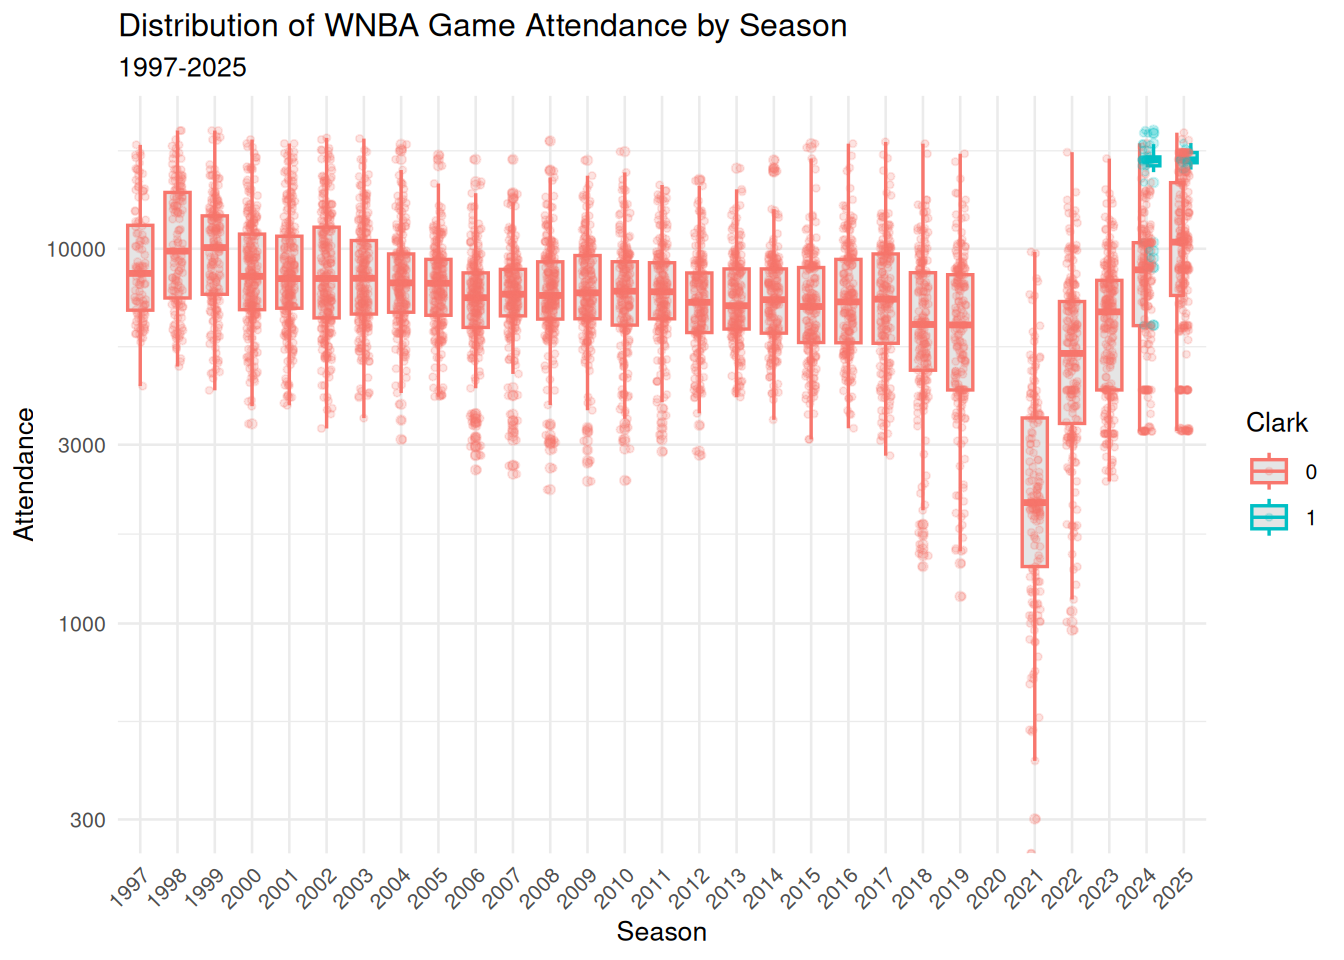

In [ ]:
ggplot(wnba_gl, aes(x = factor(season_id), y = attendance, color = factor(is_cc))) +
  geom_boxplot(outlier.alpha = 0.2, linewidth = 0.6, fill = "grey90") +
  geom_jitter(alpha = 0.2, width = 0.15, size = 1) +
  labs(
    title = "Distribution of WNBA Game Attendance by Season",
    subtitle = "1997-2025",
    x = "Season",
    y = "Attendance"
  ) +
  scale_y_log10() +
  scale_color_discrete(name = "Clark") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Estimating team strength

We used the game-level results data to model the strength of each WNBA team as a time series. Measuring team strength is necessary to test our hypothesis that attendance is in part driven by the desire of fans to see quality basketball. We considered season-to-date winning percentage and a rolling 44-game (the length of a typical WNBA season) winning percentage before settling on Elo rating \[@Elo1978\]. Originally developed for rating chess players, Elo rating is well-understood in sports analytics as a measure of team strength that updates after each game, and—unlike winning percentage and rolling winning percentage—takes into account not only the outcome but also the estimated team strength of both teams.

Let $\theta_{i}(t)$ be the strength of team $i$ at time $t$, where Elo ratings are typically centered at 1500. Then if the probability that team $i$ beats team $j$ is modeled by a logistic curve with base 10 and scale factor 400, the win probability is given by:
$$  \Pr(i \text{ beats }j \text{ at time }t) = \frac{1}{1 + 10^{\frac{\theta_{j}(t) - \theta_{i}(t)}{400}}} \,.$$
Each team starts the 1997 season with $\hat{\theta}_{i}(0) = 1500$, and following each game, team $i$’s rating is updated via the formula
$$  \hat{\theta}_{i}(t+1) = \hat{\theta}_{i}(t) + K \cdot I(i \text{ beats } j) \,,$$
where $I(i \text{ beats } j)$ is an indicator variable that is 1 if $i$ beats $j$ and $-1$ if $j$ beats $i$, and $K = 32$ is a constant that controls how sensitive the ratings are to each game. @fig-elo shows the evolution of Elo rating $\hat{\theta}_i(t)$ by franchise for the 12 teams who were active during the 2024 season. The recent poor performance of the Los Angeles Sparks, the 2010 dominance of the Seattle Storm, and the recent rise of the New York Liberty and Indiana Fever are easily visible.

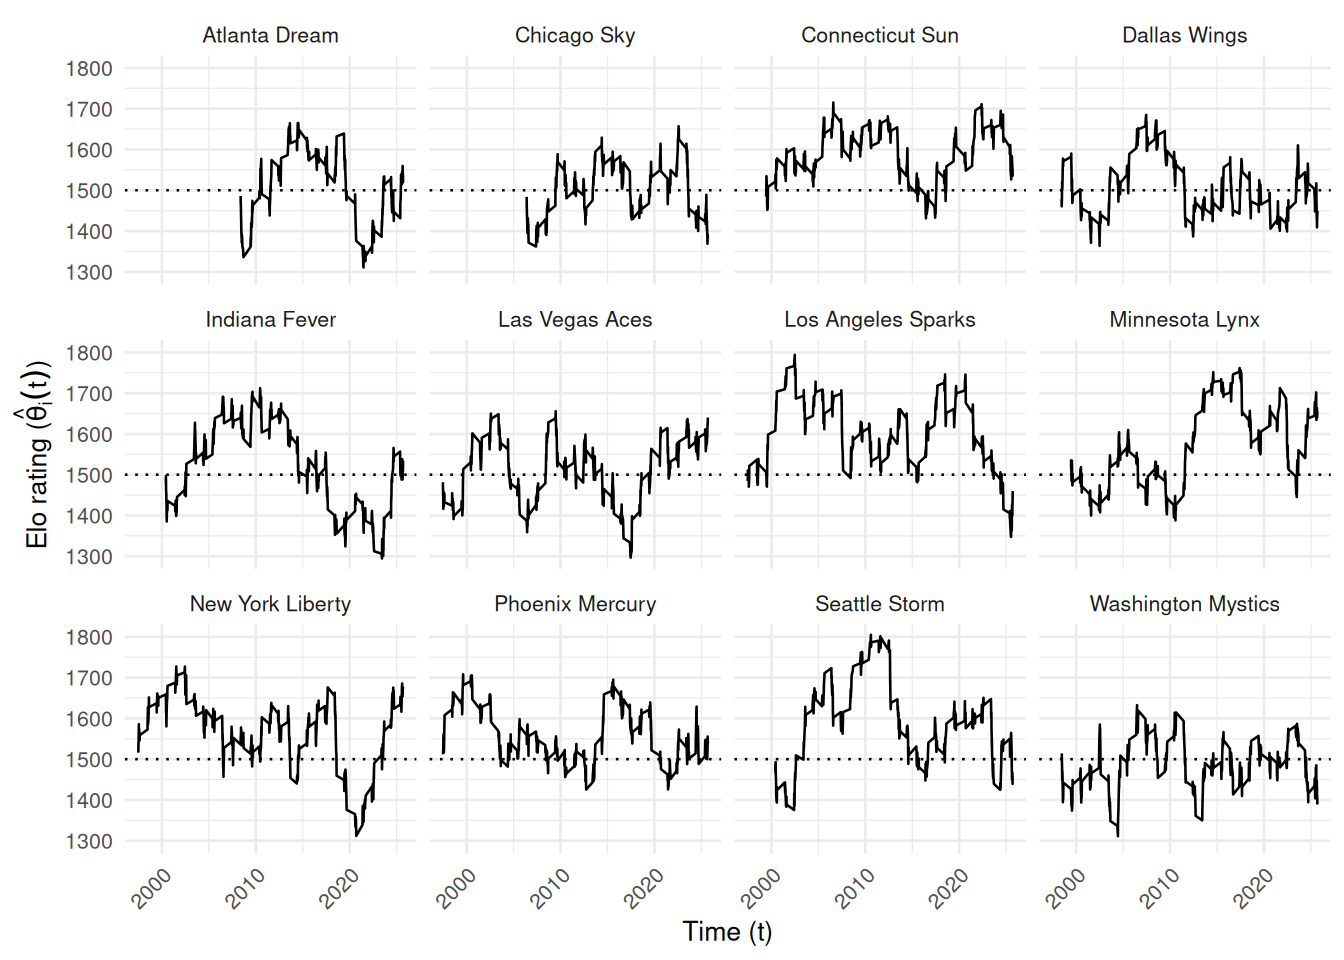

In [ ]:
wnba_gl |>
  filter(is_active, team_abbreviation != "GSV") |>
  ggplot(aes(x = game_date, y = elo.A)) +
  geom_hline(aes(yintercept = 1500), linetype = 3) +
  geom_line() +
  facet_wrap(vars(name_current)) +
  scale_y_continuous(latex2exp::TeX(r"(Elo rating ($\hat{\theta}_i(t)$))")) +
  scale_x_date("Time (t)") +
  theme_minimal(base_size = 10) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

### Estimating home win probability

The Elo ratings estimated above can then be plugged back into the win probability formula to estimate the home teams’s chances of winning. We also added a 12-point home court advantage to our home win probability model, so that:
$$  \hat{p}_{ij}(\hat{\theta}_i(t), \hat{\theta}_j(t), t) = \Pr(i \text{ beats }j \text{ at time }t \text{ at home}) = \frac{1}{1 + 10^{\frac{\hat{\theta}_{j}(t) - \left( \theta_{i}(t) + 12 \right)  }{400}}} \,.$$
We arrived at 12 points by manually calibrating the win probabilities to match the observed frequencies. While the model was less accurate at the extremes (it was consistently reluctant to predict nearly certain home wins and losses), it fit very well in the middle where most of the games occur (see @tbl-calibrate).

In [ ]:
wnba_gl |>
  group_by(wpct_bin = cut(home_win_prob, breaks = 10)) |>
  summarize(
    games = n(),
    bin_midpoint = median(home_win_prob),
    obs_home_wpct = mean(win_flag, na.rm = TRUE)
  ) |>
  mutate(diff = obs_home_wpct - bin_midpoint) |>
  janitor::clean_names(case = "title") |>
  gt() |>
  tab_header(
    title = "WNBA Home Win Probability Model Calibration (1997-2025)",
    subtitle = "10 Equally-spaced Bins"
  ) |>
  fmt_number(
    decimals = 3
  ) |>
  fmt_number(columns = Games, decimals = 0) |>
  tab_options(
    table.font.size = px(11),
    table.width = pct(100)
  )

## Methods

Our goal is to model the attendance ($y$) at a given WNBA game, as a function of several different measures of fan engagement detailed in @sec-fan. We also include several control variables to account for time and city-related effects (see @sec-control).

Since we know the arena in which the game took place and the capacity of that arena, we developed an alternative response variable- percentage of arena capacity filled ($\gamma$).

### Response variables

In @fig-attendance-year, we observe the relationship between attendance and estimated home win probability. In most years, the slope appears to be positive.

Warning in scale_y_log10("Attendance"): log-10 transformation introduced infinite values.
log-10 transformation introduced infinite values.

`geom_smooth()` using formula = 'y ~ x'

(`stat_smooth()`).

(`geom_point()`).

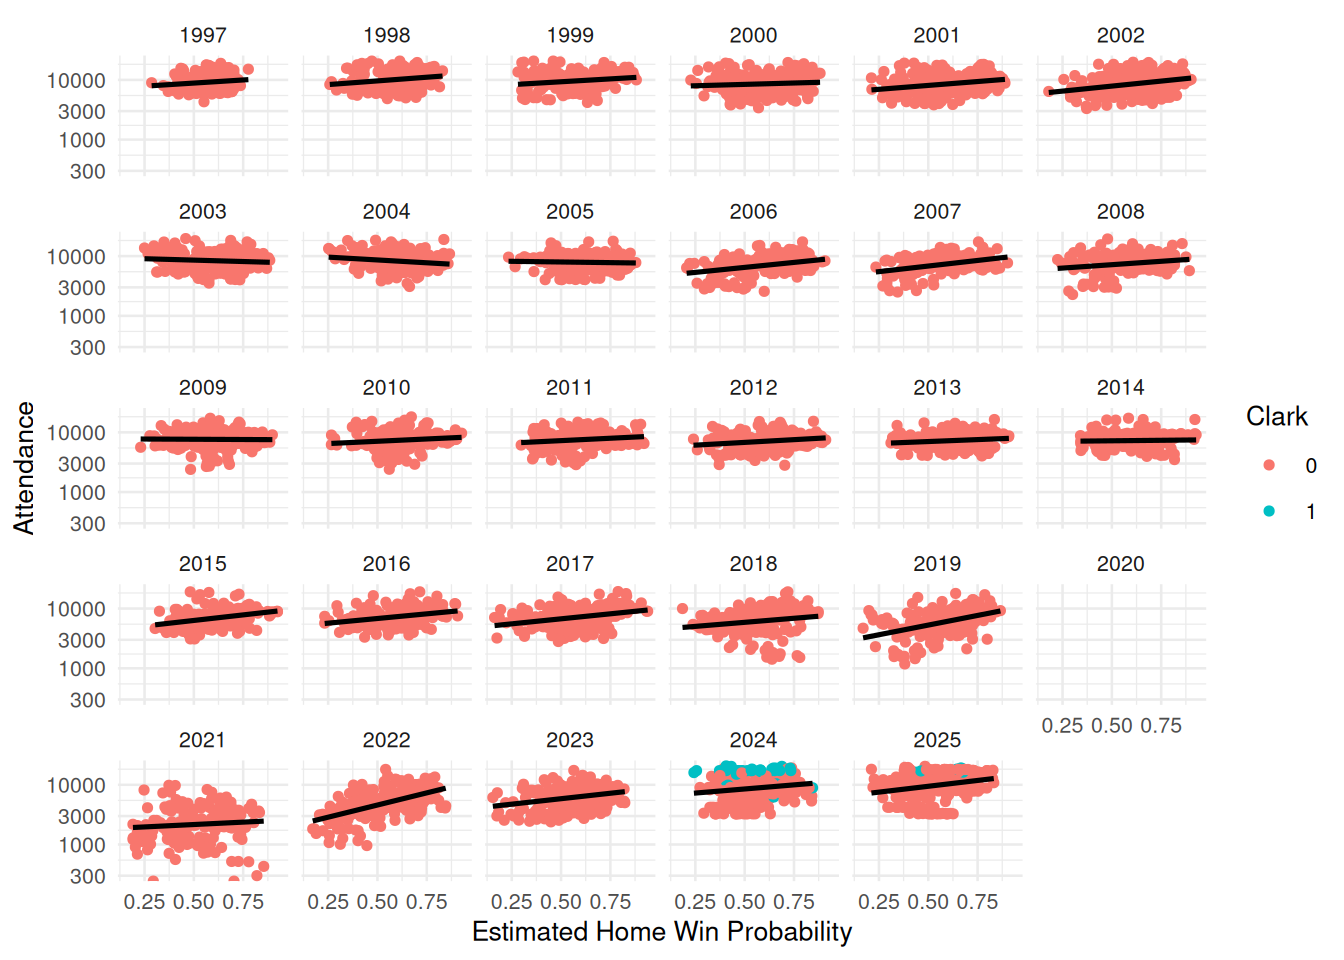

In [ ]:
ggplot(wnba_gl, aes(x = home_win_prob, y = attendance, color = factor(is_cc))) +
  geom_point() +
  geom_smooth(method = "lm", se = 0, color = "black") +
  facet_wrap(vars(season_id)) +
  scale_y_log10("Attendance") +
  scale_x_continuous("Estimated Home Win Probability") +
  scale_color_discrete(name = "Clark") +
  theme_minimal(base_size = 10)

In @fig-capacity-year, we note similar trends in the relationship between the percentage of the arena capacity filled and the estimated home win probability. We also note that since arena capacity cannot exceed 1, there are edge effects created by sellouts. Those sellouts are much more frequent in the last two years of data, and many of the sellouts involve Caitlin Clark.

`geom_smooth()` using formula = 'y ~ x'

(`stat_smooth()`).

(`geom_point()`).

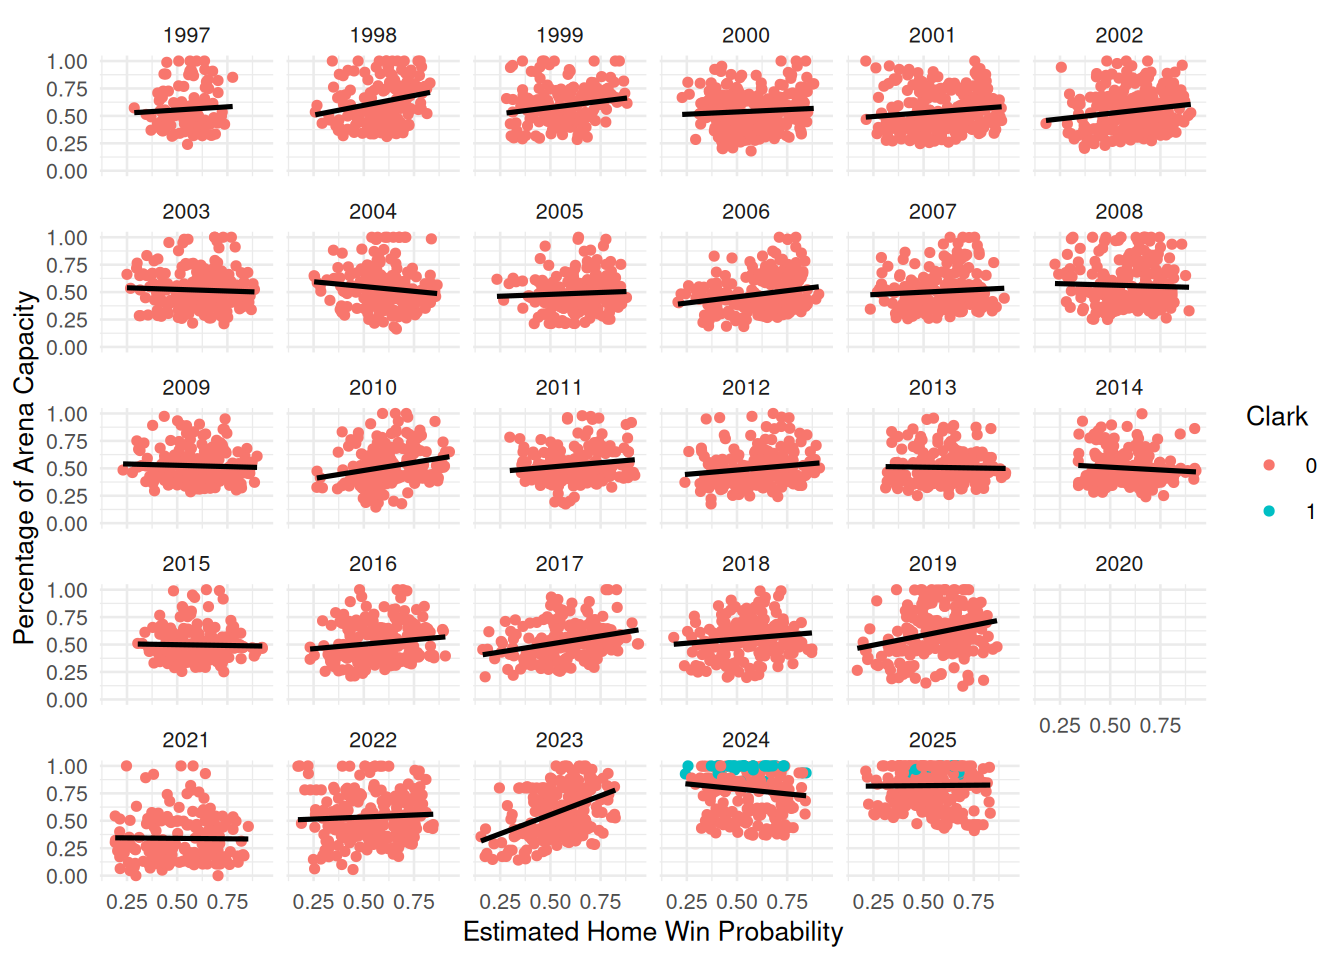

In [ ]:
wnba_gl |>
  ggplot(aes(x = home_win_prob, y = pct_capacity, color = factor(is_cc))) +
  geom_point() +
  geom_smooth(method = "lm", se = 0, color = "black") +
  facet_wrap(vars(season_id)) +
  scale_y_continuous("Percentage of Arena Capacity") +
  scale_x_continuous("Estimated Home Win Probability") +
  scale_color_discrete(name = "Clark") +
  theme_minimal(base_size = 10)

Because the raw attendance figures are not normally distributed, we model the logarithm of attendance. Similarly, because the percentage of arena capacity are bound above by 1 and below by 0, we employ a Tobit regression model.

### Modeling fan engagement

In @sec-elo, we described our use of Elo rating to estimate the strength of the home team ($\hat{\theta}_i(t)$), the strength of the visiting team ($\hat{\theta}_j(t)$) and the home win probability ($\hat{p}_{ij}(t)$) (which is itself a function of the estimated team strengths).

As noted in @sec-intro, there are multiple notions of what drives fan engagement relevant to the WNBA. Each of these notions can be captured by a simple bivariate function of the corresponding strengths of the teams ($f_k(\hat{\theta}_i(t), \hat{\theta}_i(t))$).

- Quality of play: fans may wish to attend a game in person if the quality of play is high. We model this as the sum of the Elo rating of the two teams ($f_1(\hat{\theta}_i(t), \hat{\theta}_i(t)) = \hat{\theta}_i(t) + \hat{\theta}_j(t)$)
- Loss aversion: fans may wish to attend a game to see their team (the home team) win. We model this using the estimated home win probability function above ($f_2(\hat{\theta}_i(t), \hat{\theta}_i(t)) = \hat{p}_{ij}(t)$)
- Uncertainty of outcome hypothesis: fans may wish to attend a game for which the outcome is unclear. We model this as ($f_3(\hat{\theta}_i(t), \hat{\theta}_i(t)) = |\hat{\theta}_i(t) - \hat{\theta}_j(t)|$)

### Control variables

As time-related control variables, we include the the season ($\tau_1$), the month of the year ($\tau_2$), and day of the week ($\tau_3$) as fixed effects. To control for city-related effects, we also include the team name ($\phi_1$), as well as the median income ($\phi_2$, in thousands of USD) and population ($\phi_3$, in millions) of the home city[1]. Finally, we include an indicator based on whether Caitlin Clark played more than 0 minutes in the game ($\chi$).

### Interaction

Testing our primary hypotheses requires analyzing how the relationship between attendance and fan engagement has changed over time. To capture this, we include an interaction term between our measures of fan engagement ($f_k$) and season ($\tau_1$).

### Model formulation for attendance

Like @CoatesHumphreysZhou2014, we model the natural logarithm of attendance.

Our general regression model for attendance is:
$$  \ln{y} = \beta_0^{(k)} + \beta_1^{(k)} f_k + \underbrace{\beta_2^{(k)} \tau_1 + \beta_3^{(k)} \tau_2 + \beta_4^{(k)} \tau_3}_{\text{time-related}} + \underbrace{\beta_5^{(k)} \phi_1 + \beta_6^{(k)} \phi_2 + \beta_7^{(k)} \phi_3}_{\text{ city-related }} + \beta_8^{(k)} \chi + \underbrace{\beta_9^{(k)} f_k \tau_1}_{\text{interaction}} + \epsilon \,,$$
where $k \in \{1, 2, 3\}$, and $\beta_j^{(k)} \in \mathbb{R}$ for $j = \{0, 1, 6, 7, 8\}$, while the other $\beta_j^{(k)}$ coefficients are vectors of length equal to the number of factor levels in their corresponding categorical explanatory variable. Most notably $\beta_2^{(k)}$ and $\beta_9^{(k)}$ have 29 values (corresponding to each season after 1997) and $\beta_5^{(k)}$ has 19 values (corresponding to each team). Only current WNBA franchises are included in the regression model. We also excluded all data from the 2020 and 2021 seasons, since there were no fans allowed in all or parts of both seasons.

### Model formulation for percentage of arena capacity

We fit the same set of models with $\gamma$ as the response, but the in Tobit framework.

## Results

[1] Because the population and median income statistics were available at irregular time periods (due to the COVID-19 pandemic and other factors), we chose to use the median of the population and median income across all of the available years of data as a constant value. While this does mean that the growth in cities like Phoenix or Las Vegas is ignored, we doubt this will meaningfully affect our results, especially since the team fixed effect should capture some of that variability.

In [ ]:
f_control <- "factor(season_id) + factor(wday(game_date)) + factor(month(game_date)) + name_current + median_income + median_pop + is_cc"
f_exp <- c("I(elo.A + elo.B - 3000)", "I(abs(elo.A - elo.B))", "I(home_win_prob - 0.5)")

mod_attend <- f_exp |>
  map_chr(~paste("log(attendance + 1) ~ ", .x, "* factor(season_id) +", f_control)) |>
  map(as.formula) |>
  map(lm, data = wnba_gl |>
        filter(!season_id %in% c(2021), is_active) |>
        mutate(
          median_income = median_income / 1000,
          median_pop = median_pop / 1000000
        )
  ) |>
  set_names(nm = paste0("f", 1:3))

#mod_attend |>
#  map(summary)

### Attendance

In keeping with recent guidance from @wasserstein2016asa and @wasserstein2019moving, and with a sample size of over 5000 observations and dozens of coefficients, we are less interested in the p-values shown in @tbl-coefs, and focus our attention on the magnitude and practical impact of the fitted coefficients. (All variables except for population achieve “statistical significance” at the 5%-level, as shown in @tbl-anova). Residual analysis for the attendance models are shown in @sec-resid-attend.

In [ ]:
mod_attend_coefs <- mod_attend |>
  map(broom::tidy) |>
  bind_rows(.id = "model") 

mod_attend_coefs |>
  filter_out(str_detect(term, "factor|name_current")) |>
  arrange(term, model) |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

  ----------------------------------------------------------------------------
  Model   Term                        Estimate  Std Error   Statistic  P Value
  ------- ------------------------- ---------- ---------- ----------- --------
  f1      (Intercept)                    9.027      0.129      69.908    0.000

  f2      (Intercept)                    8.968      0.155      58.003    0.000

  f3      (Intercept)                    9.078      0.132      68.750    0.000

  f2      I(abs(elo.A - elo.B))          0.001      0.001       0.524    0.600

  f1      I(elo.A + elo.B - 3000)        0.002      0.001       3.320    0.001

  f3      I(home_win_prob - 0.5)         0.422      0.402       1.050    0.294

  f1      is_cc                          0.705      0.049      14.514    0.000

  f2      is_cc                          0.699      0.050      14.089    0.000

  f3      is_cc                          0.653      0.048      13.627    0.000

  f1      median_income                 -0.007      0.002      -3.687    0.000

  f2      median_income                 -0.006      0.002      -3.144    0.002

  f3      median_income                 -0.008      0.002      -4.003    0.000

  f1      median_pop                     0.021      0.007       2.967    0.003

  f2      median_pop                     0.014      0.007       1.888    0.059

  f3      median_pop                     0.017      0.007       2.382    0.017
  ----------------------------------------------------------------------------


Consider first the strong evidence for the Caitlin Clark effect. Even for the smallest coefficient in @tbl-coefs, the expected attendance nearly doubles (i.e., is multiplied by $\exp(0.653)$ = 1.92) when Clark plays in the game, and this is *after* controlling for the Indiana Fever team effect, the level of fan engagement, and the season effects!

Conversely, the evidence for the quality of play and uncertainty of outcome hypotheses is weak, with those coefficients barely moving the needle. A 10 percentage point increase in the probability of the home team winning is associated with a modest 4.31% increase in the expected attendance, after controlling for our other factors.

In [ ]:
mod_attend |>
  map(anova) |>
  map(broom::tidy) |>
  bind_rows(.id = "model") |>
  filter_out(str_detect(term, "Residuals")) |>
  arrange(df, term, model) |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

  ---------------------------------------------------------------------------------------
  Model   Term                                  Df     Sumsq   Meansq   Statistic P Value
  ------- ----------------------------------- ---- --------- -------- ----------- -------
  f2      I(abs(elo.A - elo.B))                  1    10.851   10.851      99.987   0.000

  f1      I(elo.A + elo.B - 3000)                1    40.473   40.473     401.255   0.000

  f3      I(home_win_prob - 0.5)                 1    39.923   39.923     395.845   0.000

  f1      is_cc                                  1    22.763   22.763     225.675   0.000

  f2      is_cc                                  1    21.472   21.472     197.854   0.000

  f3      is_cc                                  1    19.936   19.936     197.668   0.000

  f1      median_income                          1     1.502    1.502      14.890   0.000

  f2      median_income                          1     1.307    1.307      12.039   0.001

  f3      median_income                          1     1.629    1.629      16.153   0.000

  f1      median_pop                             1     0.278    0.278       2.759   0.097

  f2      median_pop                             1     0.322    0.322       2.964   0.085

  f3      median_pop                             1     0.154    0.154       1.528   0.216

  f1      factor(month(game_date))               4    12.644    3.161      31.339   0.000

  f2      factor(month(game_date))               4    12.434    3.109      28.645   0.000

  f3      factor(month(game_date))               4    11.842    2.960      29.354   0.000

  f1      factor(wday(game_date))                6    14.323    2.387      23.667   0.000

  f2      factor(wday(game_date))                6    15.293    2.549      23.487   0.000

  f3      factor(wday(game_date))                6    14.704    2.451      24.300   0.000

  f1      name_current                          12   117.498    9.791      97.074   0.000

  f2      name_current                          12   132.317   11.026     101.605   0.000

  f3      name_current                          12   122.443   10.204     101.171   0.000

  f2      I(abs(elo.A -                         26     6.526    0.251       2.313   0.000
          elo.B)):factor(season_id)                                               

  f1      I(elo.A + elo.B -                     26    27.457    1.056      10.470   0.000
          3000):factor(season_id)                                                 

  f3      I(home_win_prob -                     26    31.440    1.209      11.990   0.000
          0.5):factor(season_id)                                                  

  f1      factor(season_id)                     26   152.181    5.853      58.029   0.000

  f2      factor(season_id)                     26   150.433    5.786      53.315   0.000

  f3      factor(season_id)                     26   147.101    5.658      56.098   0.000
  ---------------------------------------------------------------------------------------


@tbl-glance characterizes the model fits. We can see that while all models achieve a similar fit, models $f_1$ (corresponding to the quality of play hypothesis) and $f_3$ (corresponding to the home win probability) are slightly superior by most metrics.

In [ ]:
mod_attend |>
  map(broom::glance) |>
  bind_rows(.id = "model") |>
  knitr::kable(digits = 3)

  ----------------------------------------------------------------------------------------------------------------------------------------
  model     r.squared   adj.r.squared   sigma   statistic   p.value   df      logLik        AIC        BIC   deviance   df.residual   nobs
  ------- ----------- --------------- ------- ----------- --------- ---- ----------- ---------- ---------- ---------- ------------- ------
  f1            0.436           0.427   0.318      49.459         0   78   -1337.102   2834.204   3356.582    502.715          4984   5063

  f2            0.394           0.384   0.329      41.460         0   78   -1522.340   3204.680   3727.057    540.879          4984   5063

  f3            0.436           0.428   0.318      49.471         0   78   -1336.828   2833.656   3356.033    502.660          4984   5063
  ----------------------------------------------------------------------------------------------------------------------------------------


@fig-season-coefs shows that after controlling for the Caitlin Clark effect, expected attendance is only just returning its 1997 baseline in the most recent season. This is a mixed blessing. On the one hand, even after controlling for Clark, league expected attendance has fully recovered from the COVID-19 pandemic and the malaise of the early 2000s and 2010s. On the other hand, it seems unlikely that the league would have achieved record high attendance without Clark.

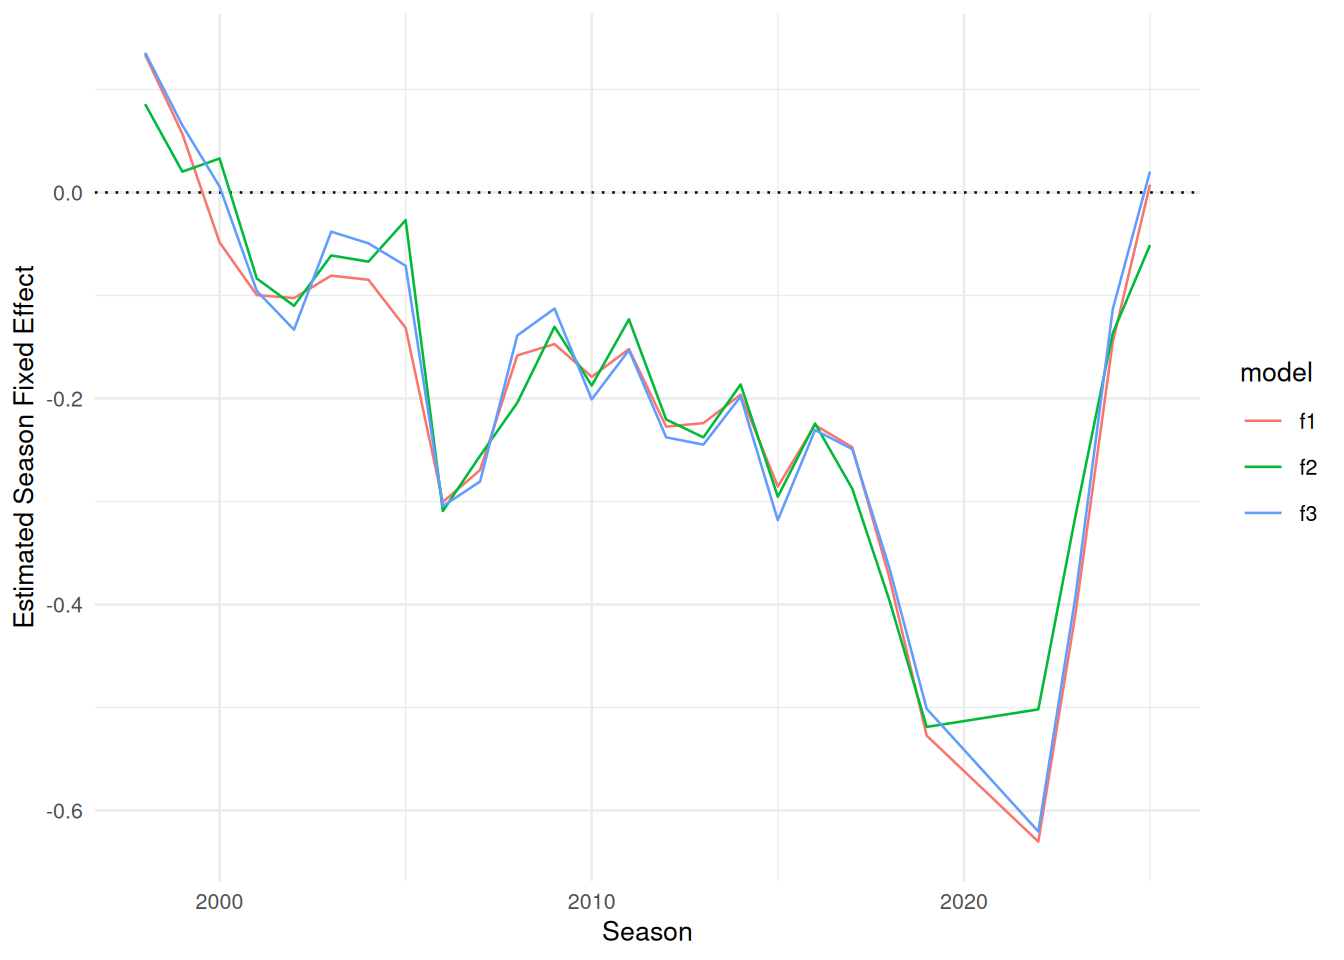

In [ ]:
mod_attend_coefs |>
  filter(str_detect(term, "season_id")) |>
  filter_out(str_detect(term, ":")) |>
  mutate(season_id = parse_number(str_sub(term, -4))) |>
  ggplot(aes(x = season_id, y = estimate, color = model)) +
  geom_hline(yintercept = 0, linetype = 3) +
  geom_line() +
  scale_x_continuous("Season") +
  scale_y_continuous("Estimated Season Fixed Effect") +
  theme_minimal(base_size = 10)

@fig-season-slopes shows a general increase in the slope of the interaction terms in all three models in recent years. For all three models, these change in slope coefficients were decidedly negative until around 2015. This suggests that the relationship between attendance and fan engagement was more moderate during those years. (Note that for all three models, the main effect of the fan engagement term in @tbl-coefs is positive.) While the change in slope associated with model $f_1$ is still negative, it is closer to zero than it has been in the past. The changes in slope associated with models $f_2$ and $f_3$ are now positive, although it is difficult to assess the long-term trend due to the pandemic being only a few years past.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

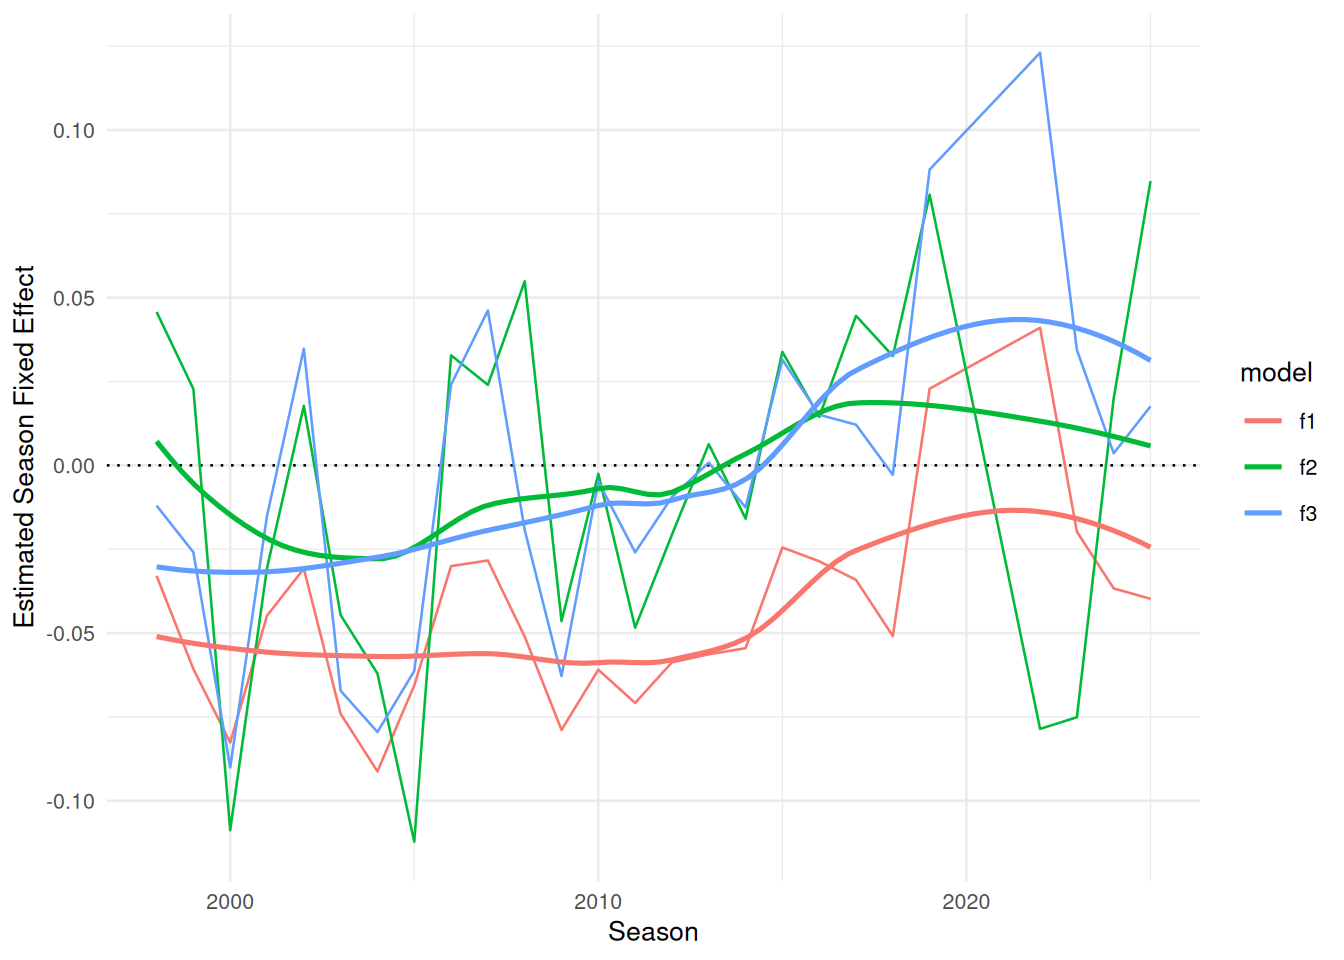

In [ ]:
mod_attend_coefs |>
  filter(str_detect(term, ":")) |>
  mutate(
    season_id = parse_number(str_sub(term, -4)),
    type = ifelse(str_detect(term, ":"), "interaction", "linear"),
    scaled_estimate = case_when(
      model == "f1" ~ estimate * (mean(wnba_gl$elo.A + wnba_gl$elo.B - 3000)),
      model == "f2" ~ estimate * (mean(abs(wnba_gl$elo.A - wnba_gl$elo.B))),
      model == "f3" ~ estimate * (mean(wnba_gl$home_win_prob - 0.5))
    )
  ) |>
  ggplot(aes(x = season_id, y = scaled_estimate, color = model)) +
  geom_hline(yintercept = 0, linetype = 3) +
  geom_line() +
  geom_smooth(se = 0) +
  scale_x_continuous("Season") +
  scale_y_continuous("Estimated Season Fixed Effect") +
  theme_minimal(base_size = 10)

### Percentage of Arena Capacity

Because our response variable $\gamma$ is constrained between 0 and 1, but has significant mass at 1 exactly, we fit a Papke-Wooldridge fractional response model \[@papke1996econometric\] with HC1 sandwich estimators for the covariance matrix.

In [ ]:
library(lmtest)

Loading required package: zoo


Attaching package: 'zoo'

The following objects are masked from 'package:base':

    as.Date, as.Date.numeric

Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!

@tbl-coefs2 reports the coefficients from the percentage of arena capacity models.

In [ ]:
mod_pct_coefs <- map2(mod_pct, vcov_pct, lmtest::coeftest) |>
  map(broom::tidy) |>
  bind_rows(.id = "model") 

mod_pct_coefs |>
  filter_out(str_detect(term, "factor|name")) |>
  knitr::kable()

  ---------------------------------------------------------------------------------
  model   term                        estimate   std.error    statistic     p.value
  ------- ----------------------- ------------ ----------- ------------ -----------
  f1      (Intercept)                0.0420351   0.3060837    0.1373320   0.8907684

  f1      I(elo.A + elo.B - 3000)    0.0053038   0.0012483    4.2489239   0.0000215

  f1      median_income              0.0192855   0.0046684    4.1310605   0.0000361

  f1      median_pop                -0.0975090   0.0147117   -6.6279729   0.0000000

  f1      is_cc                      2.8268291   0.2623045   10.7768979   0.0000000

  f2      (Intercept)                0.3066991   0.3737256    0.8206531   0.4118439

  f2      I(abs(elo.A - elo.B))     -0.0012487   0.0029263   -0.4267265   0.6695786

  f2      median_income              0.0164644   0.0046623    3.5314191   0.0004133

  f2      median_pop                -0.0948250   0.0144747   -6.5511069   0.0000000

  f2      is_cc                      2.9022797   0.2595776   11.1807804   0.0000000

  f3      (Intercept)                0.0502670   0.3202932    0.1569407   0.8752916

  f3      I(home_win_prob - 0.5)     2.3584200   0.8986874    2.6242941   0.0086829

  f3      median_income              0.0179402   0.0047330    3.7904230   0.0001504

  f3      median_pop                -0.1017634   0.0149716   -6.7970886   0.0000000

  f3      is_cc                      2.8717453   0.2611669   10.9958230   0.0000000
  ---------------------------------------------------------------------------------


@tbl-glance2 shows the model fit metrics for the percentage of arena capacity models.

In [ ]:
mod_pct |>
  map(broom::glance) |>
  bind_rows(.id = "model") |>
  knitr::kable()

  ---------------------------------------------------------------------------------------------------
  model     null.deviance   df.null      logLik        AIC        BIC   deviance   df.residual   nobs
  ------- --------------- --------- ----------- ---------- ---------- ---------- ------------- ------
  f1             916.6665      5062   -2973.023   6104.046   6619.894   559.5177          4984   5063

  f2             916.6665      5062   -2999.275   6156.550   6672.398   574.1421          4984   5063

  f3             916.6665      5062   -2986.255   6130.510   6646.358   564.3610          4984   5063
  ---------------------------------------------------------------------------------------------------


@tbl-anova2 shows the analysis of variance for the percentage of arena capacity models.

In [ ]:
mod_pct |>
  map(anova) |>
  map(broom::tidy) |>
  bind_rows(.id = "model") |>
  filter_out(str_detect(term, "NULL")) |>
  arrange(df, term, model) |>
  janitor::clean_names(case = "title") |>
  knitr::kable(digits = 3)

Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a binomial glm!
Warning in eval(family$initialize): non-integer #successes in a 

  ---------------------------------------------------------------------------------------
  Model   Term                             Df   Deviance         Df      Residual P Value
                                                           Residual      Deviance 
  ------- ------------------------------ ---- ---------- ---------- ------------- -------
  f2      I(abs(elo.A - elo.B))             1      0.032       5061       916.634   0.858

  f1      I(elo.A + elo.B - 3000)           1      8.035       5061       908.631   0.005

  f3      I(home_win_prob - 0.5)            1      0.906       5061       915.760   0.341

  f1      is_cc                             1     24.002       5010       573.411   0.000

  f2      is_cc                             1     23.389       5010       581.441   0.000

  f3      is_cc                             1     22.520       5010       579.403   0.000

  f1      median_income                     1      0.977       5012       601.451   0.323

  f2      median_income                     1      1.038       5012       608.706   0.308

  f3      median_income                     1      0.972       5012       606.342   0.324

  f1      median_pop                        1      4.038       5011       597.414   0.044

  f2      median_pop                        1      3.876       5011       604.830   0.049

  f3      median_pop                        1      4.419       5011       601.923   0.036

  f1      factor(month(game_date))          4     13.370       5025       696.118   0.010

  f2      factor(month(game_date))          4     13.218       5025       706.988   0.010

  f3      factor(month(game_date))          4     12.953       5025       701.429   0.012

  f1      factor(wday(game_date))           6     18.624       5029       709.487   0.005

  f2      factor(wday(game_date))           6     18.719       5029       720.205   0.005

  f3      factor(wday(game_date))           6     19.034       5029       714.381   0.004

  f1      name_current                     12     93.689       5013       602.429   0.000

  f2      name_current                     12     97.243       5013       609.745   0.000

  f3      name_current                     12     94.115       5013       607.314   0.000

  f2      I(abs(elo.A -                    26      7.299       4984       574.142   1.000
          elo.B)):factor(season_id)                                               

  f1      I(elo.A + elo.B -                26     13.894       4984       559.518   0.974
          3000):factor(season_id)                                                 

  f3      I(home_win_prob -                26     15.042       4984       564.361   0.957
          0.5):factor(season_id)                                                  

  f1      factor(season_id)                26    180.519       5035       728.112   0.000

  f2      factor(season_id)                26    177.710       5035       738.924   0.000

  f3      factor(season_id)                26    182.345       5035       733.416   0.000
  ---------------------------------------------------------------------------------------


@fig-season-coefs2 shows that…

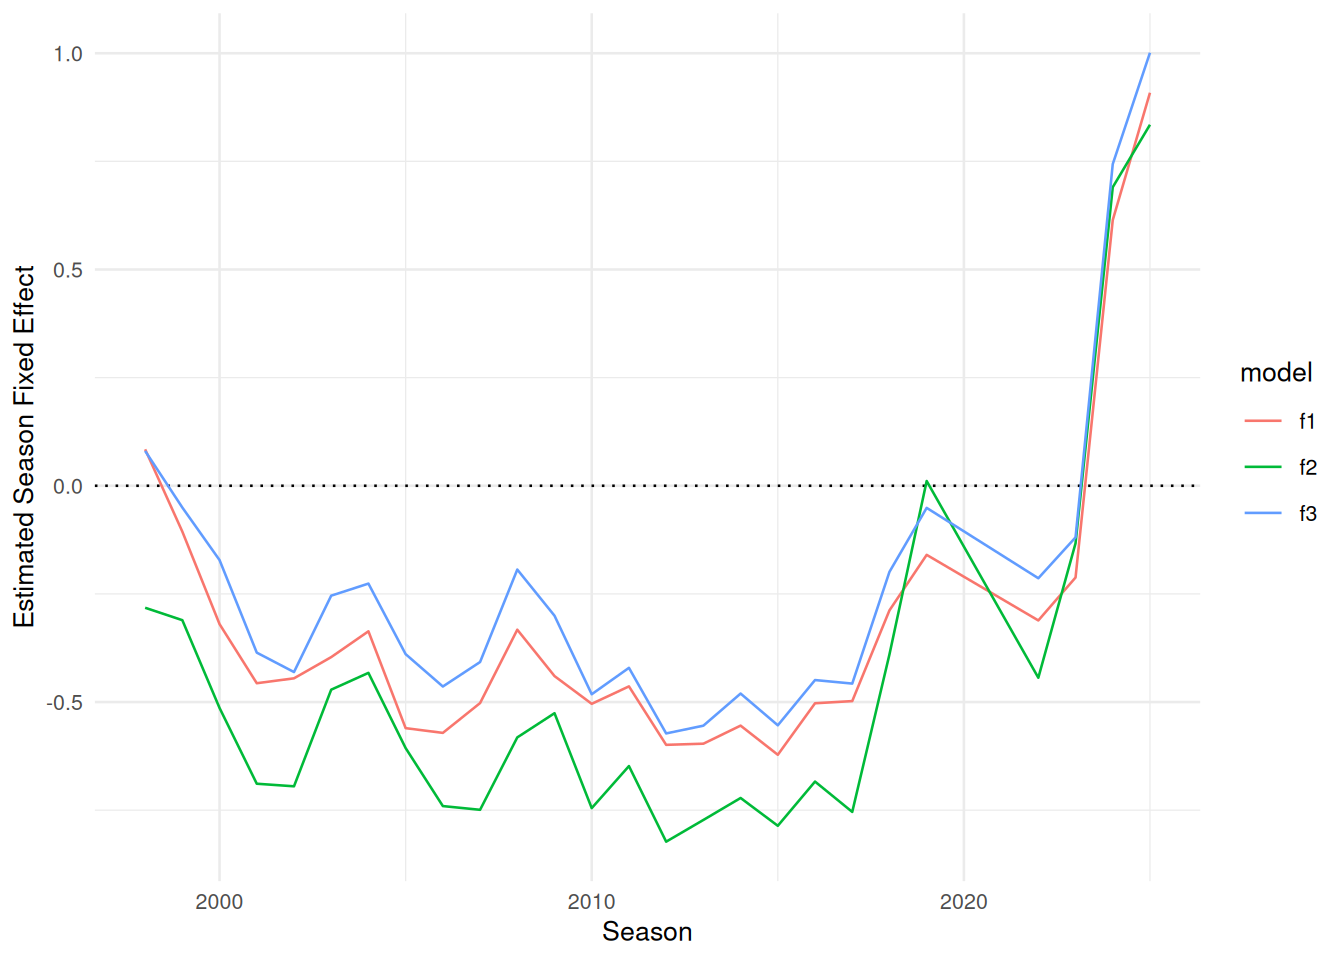

In [ ]:
mod_pct_coefs |>
  filter(str_detect(term, "season_id")) |>
  filter_out(str_detect(term, ":")) |>
  mutate(season_id = parse_number(str_sub(term, -4))) |>
  ggplot(aes(x = season_id, y = estimate, color = model)) +
  geom_hline(yintercept = 0, linetype = 3) +
  geom_line() +
  scale_x_continuous("Season") +
  scale_y_continuous("Estimated Season Fixed Effect") +
  theme_minimal(base_size = 10)

@fig-season-slopes2 shows that…

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'

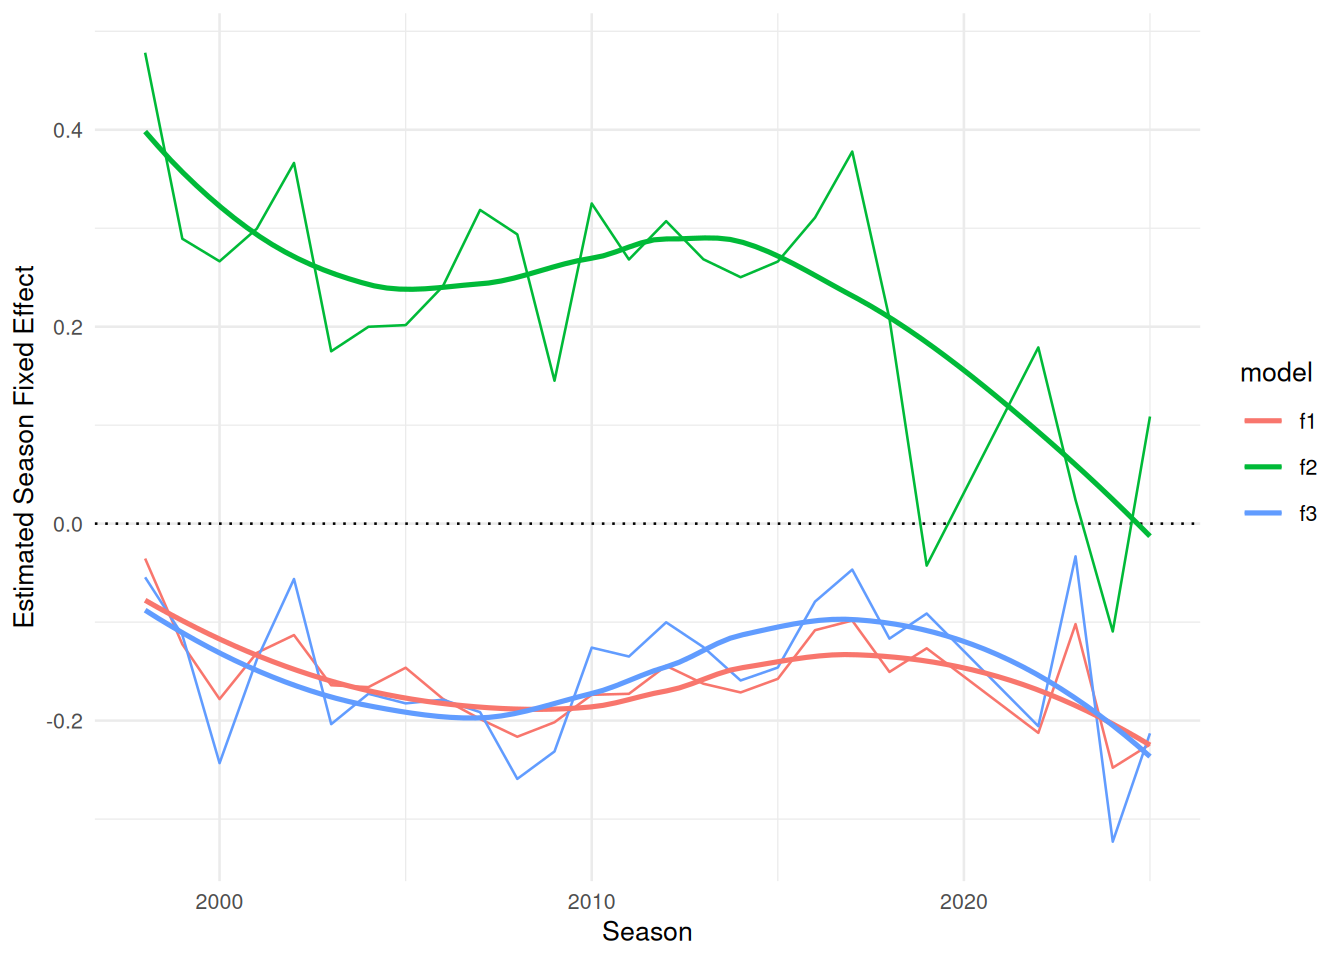

In [ ]:
mod_pct_coefs |>
  filter(str_detect(term, ":")) |>
  mutate(
    season_id = parse_number(str_sub(term, -4)),
    type = ifelse(str_detect(term, ":"), "interaction", "linear"),
    scaled_estimate = case_when(
      model == "f1" ~ estimate * (mean(wnba_gl$elo.A + wnba_gl$elo.B - 3000)),
      model == "f2" ~ estimate * (mean(abs(wnba_gl$elo.A - wnba_gl$elo.B))),
      model == "f3" ~ estimate * (mean(wnba_gl$home_win_prob - 0.5))
    )
  ) |>
  ggplot(aes(x = season_id, y = scaled_estimate, color = model)) +
  geom_hline(yintercept = 0, linetype = 3) +
  geom_line() +
  geom_smooth(se = 0) +
  scale_x_continuous("Season") +
  scale_y_continuous("Estimated Season Fixed Effect") +
  theme_minimal(base_size = 10)

## Conclusion

### Limitations

Because the percentage of arena capacity data is right-censored, we considered a Tobit regression model \[@mcdonald1980uses\], but our residuals violated the normality and homoskedasticity conditions. We also considered fitting a Beta regression model with a logit link function, and converting the fixed effects for seasons to random effects, but those models didn’t converge.

### Future work

### Discussion

## References

## Appendix

### Residual analysis of attendance models

``` r
mod_attend |>
  map(plot, ask = FALSE)
```

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output cell-output-stdout" width="50.0%" data-layout-align="left">
<pre><code>$f1
NULL
&#10;$f2
NULL
&#10;$f3
NULL</code></pre>
</div></td>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>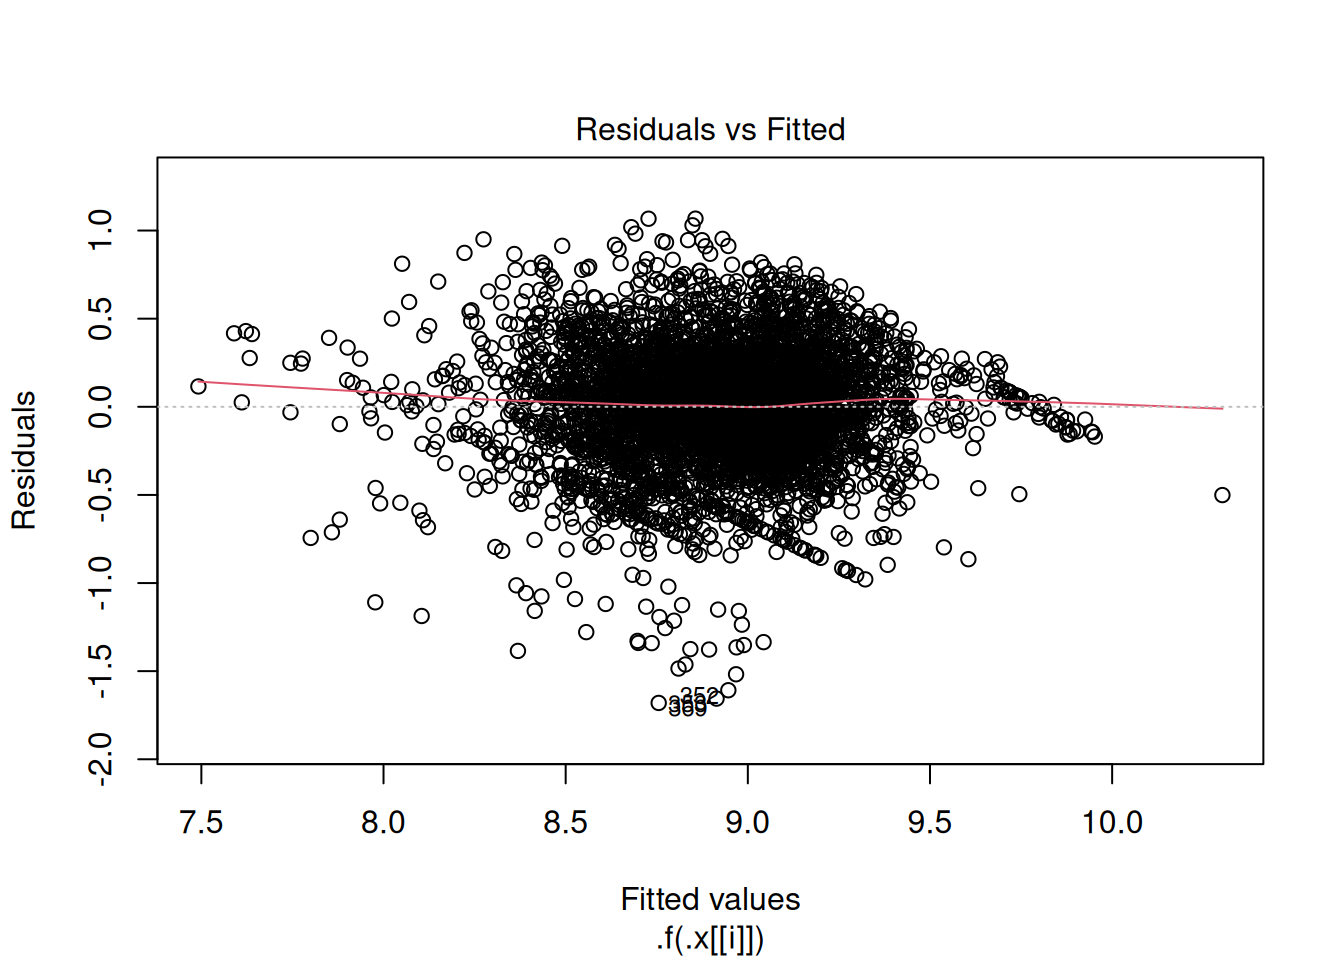</p>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>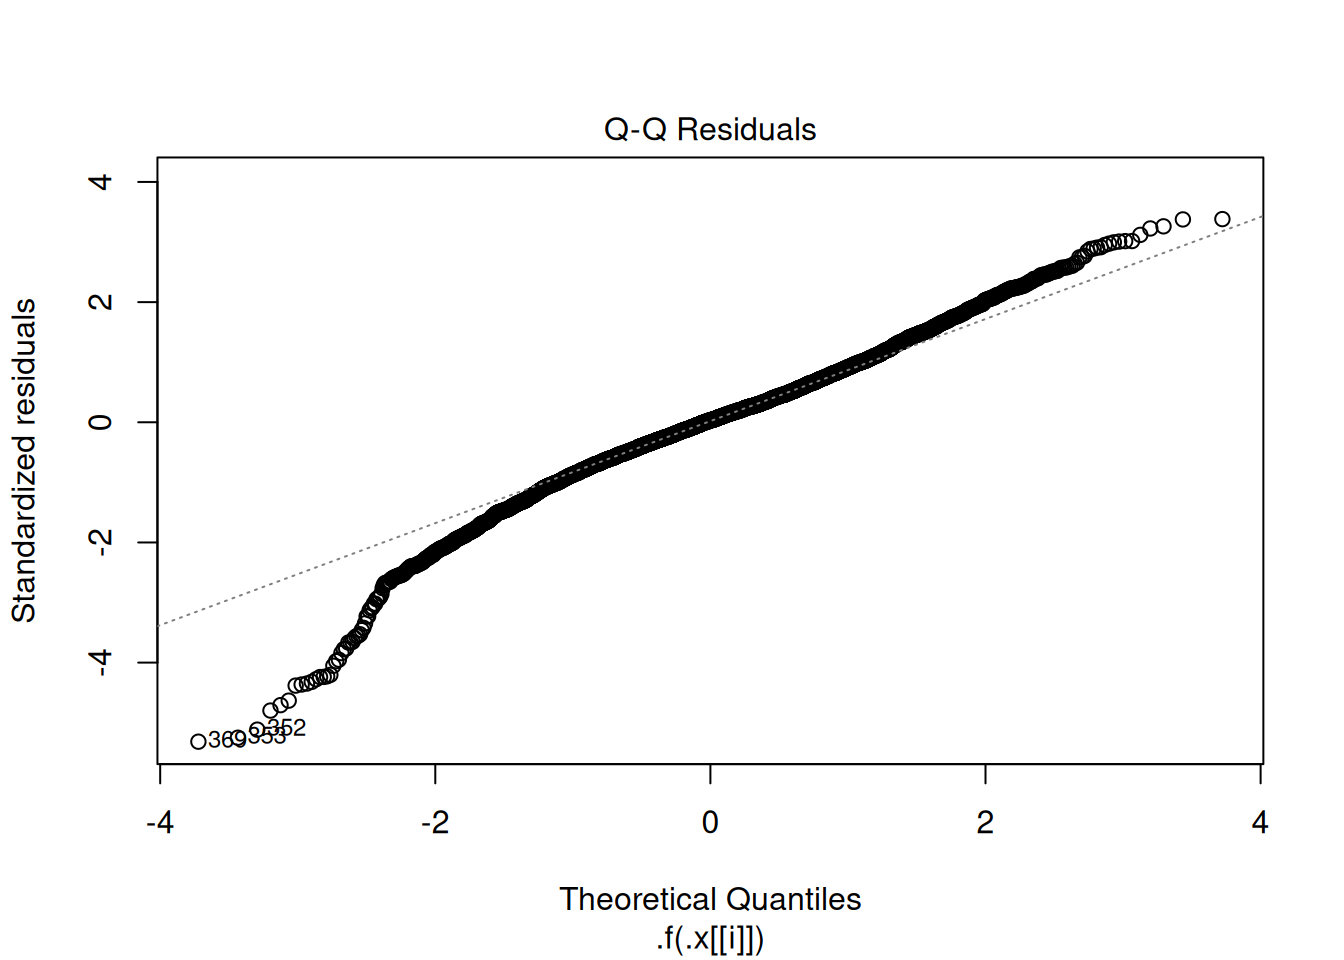</p>
</div></td>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>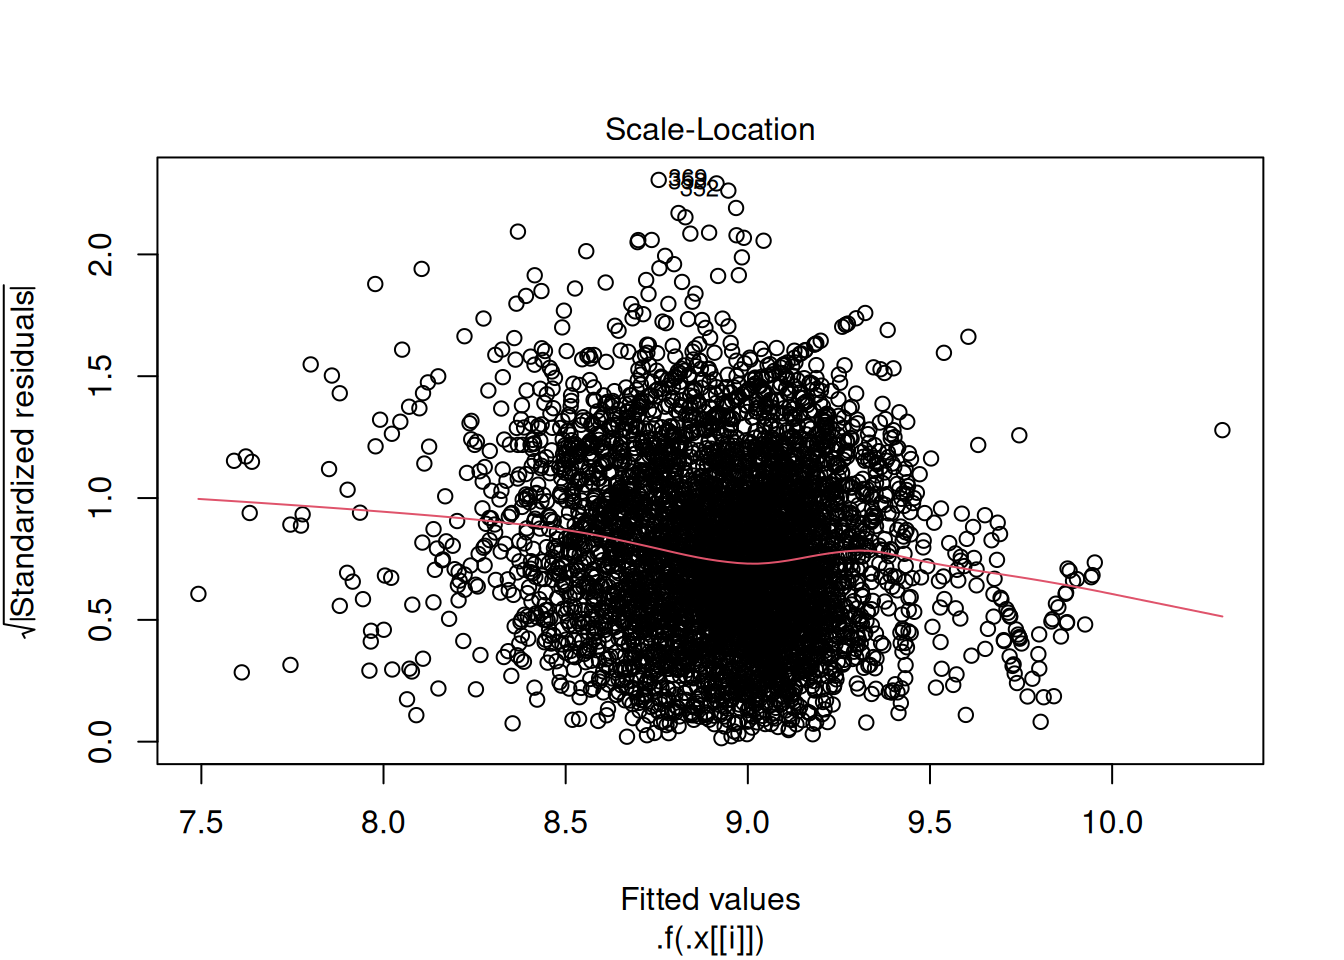</p>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>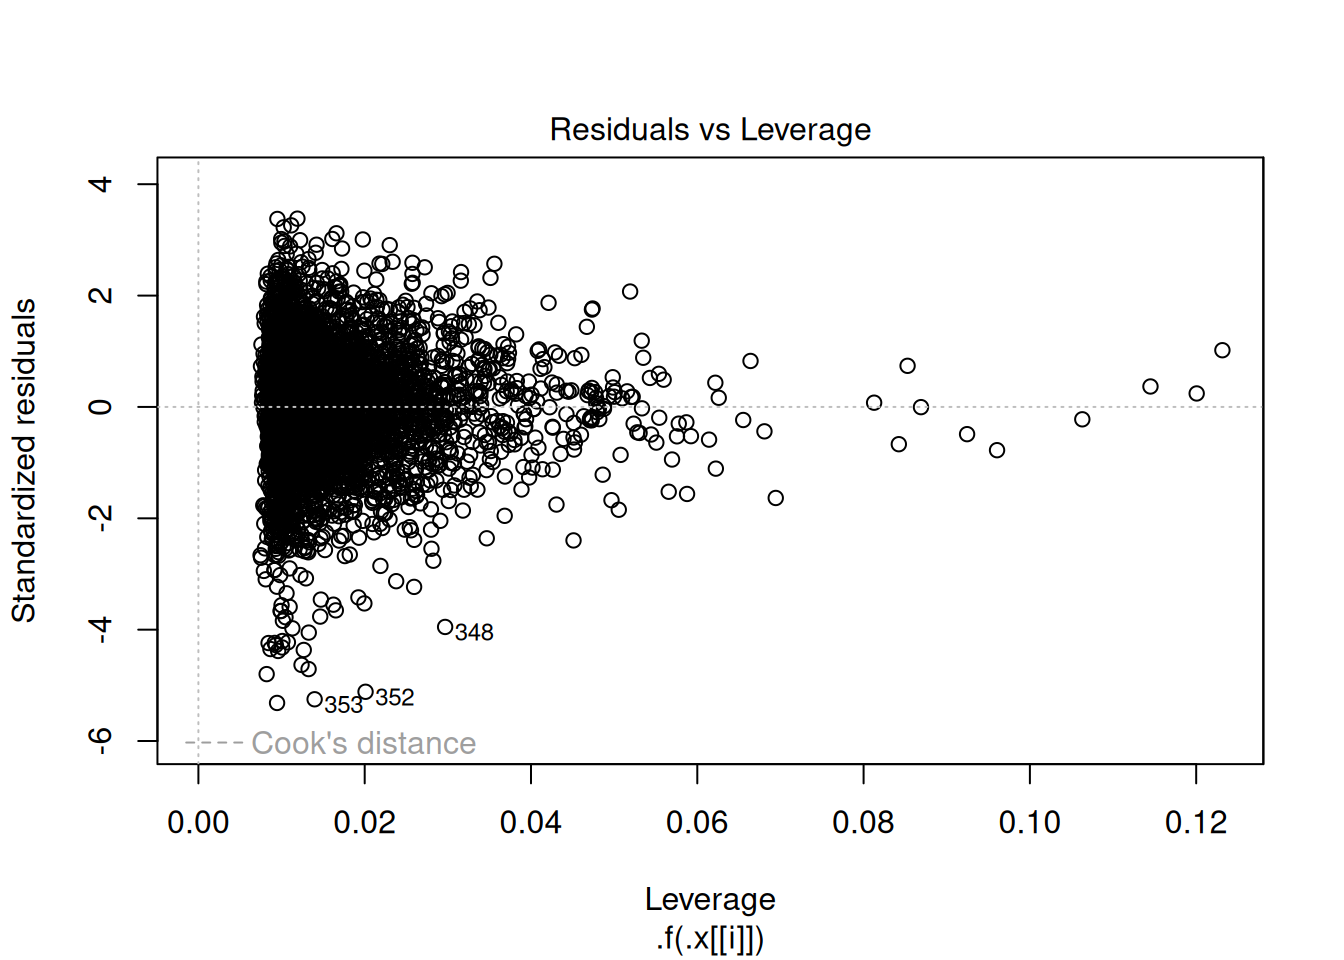</p>
</div></td>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>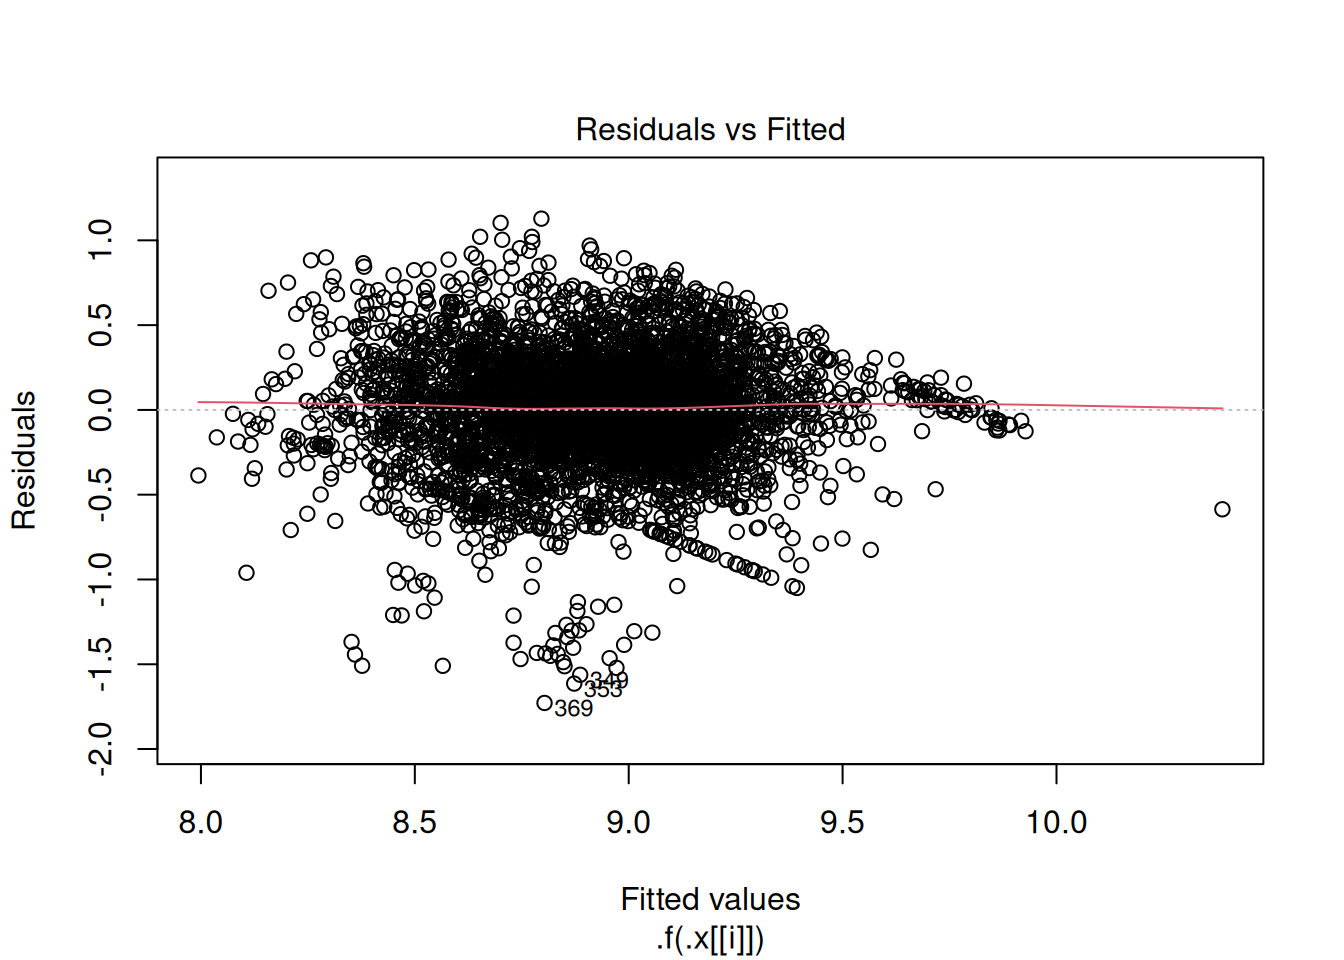</p>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>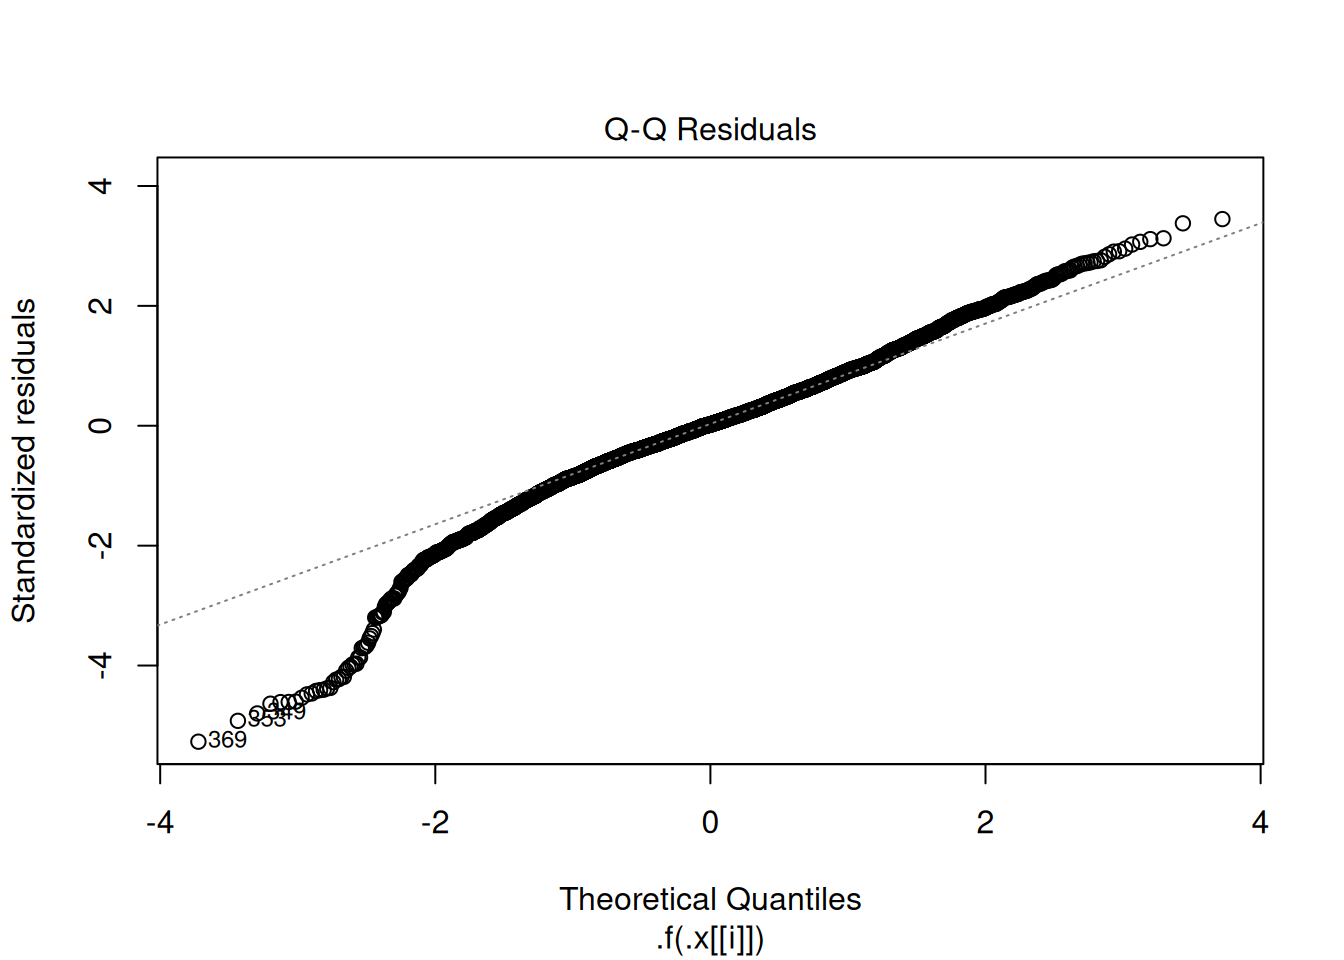</p>
</div></td>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>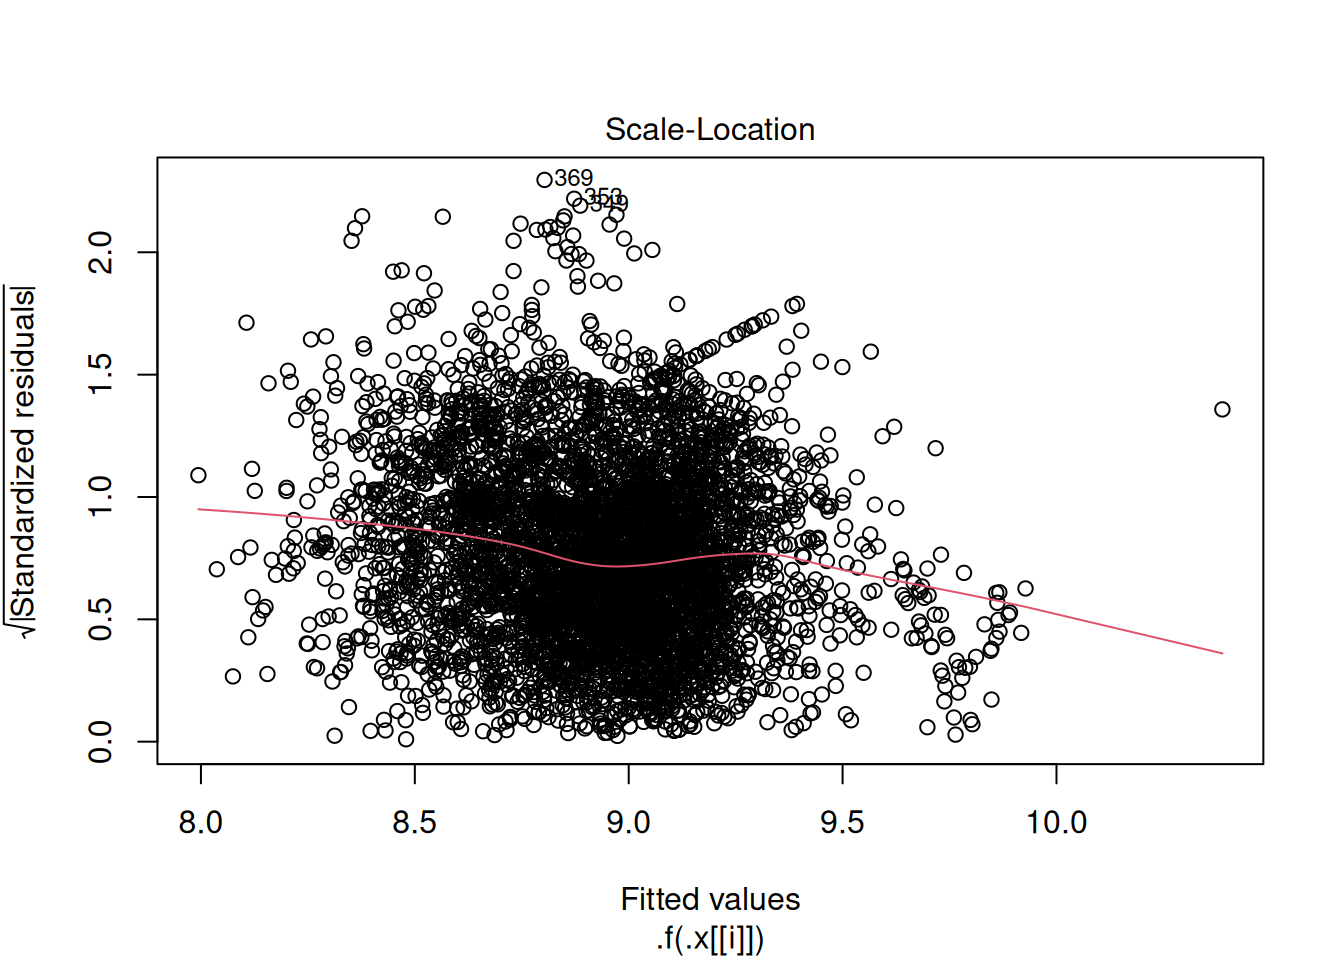</p>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>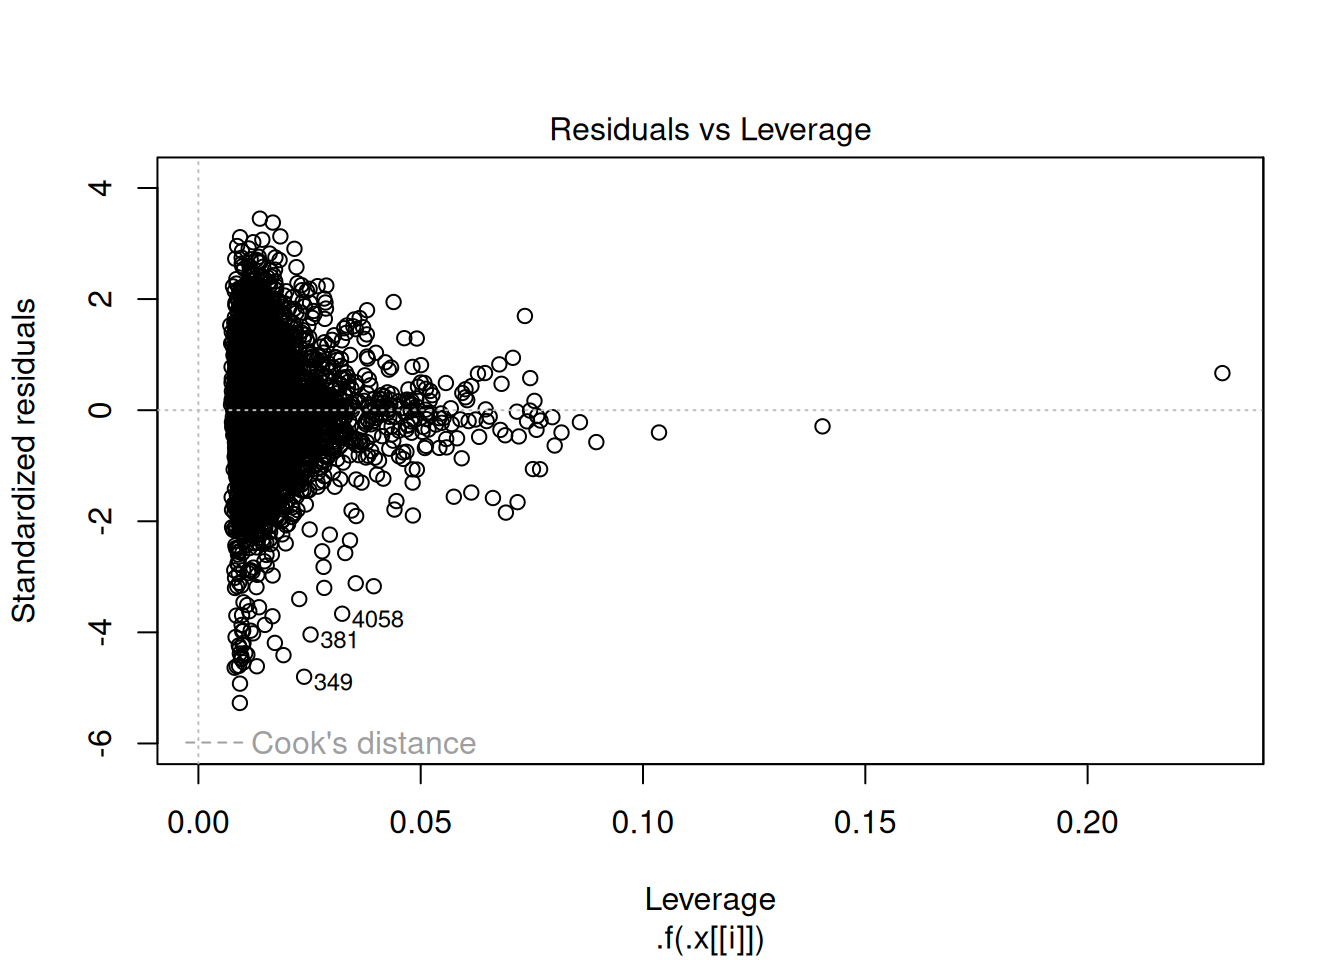</p>
</div></td>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>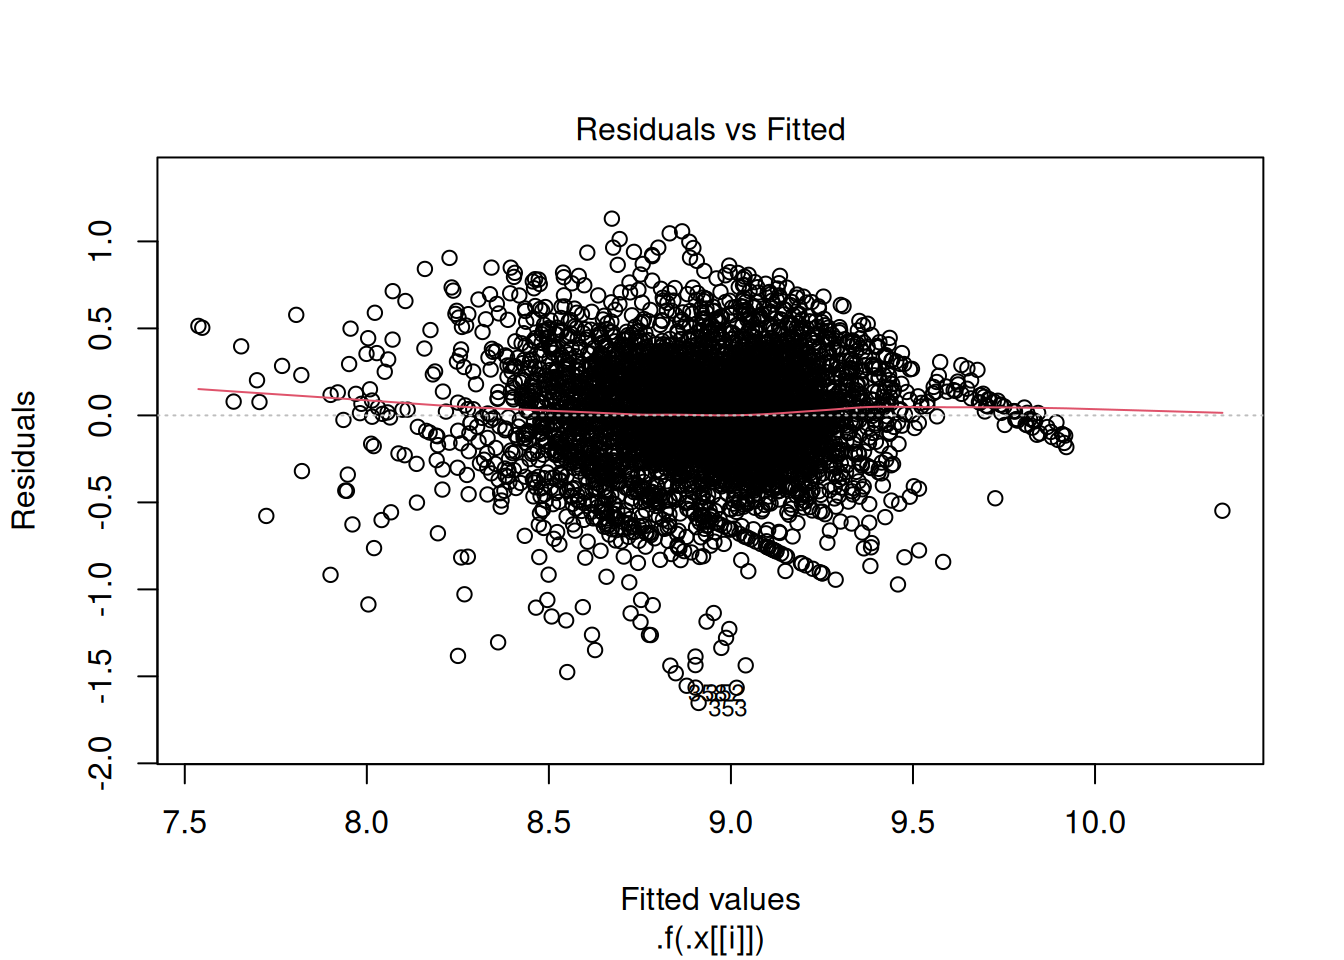</p>
</div></td>
</tr>
</tbody>
</table>

<table>
<colgroup>
<col style="width: 50%" />
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>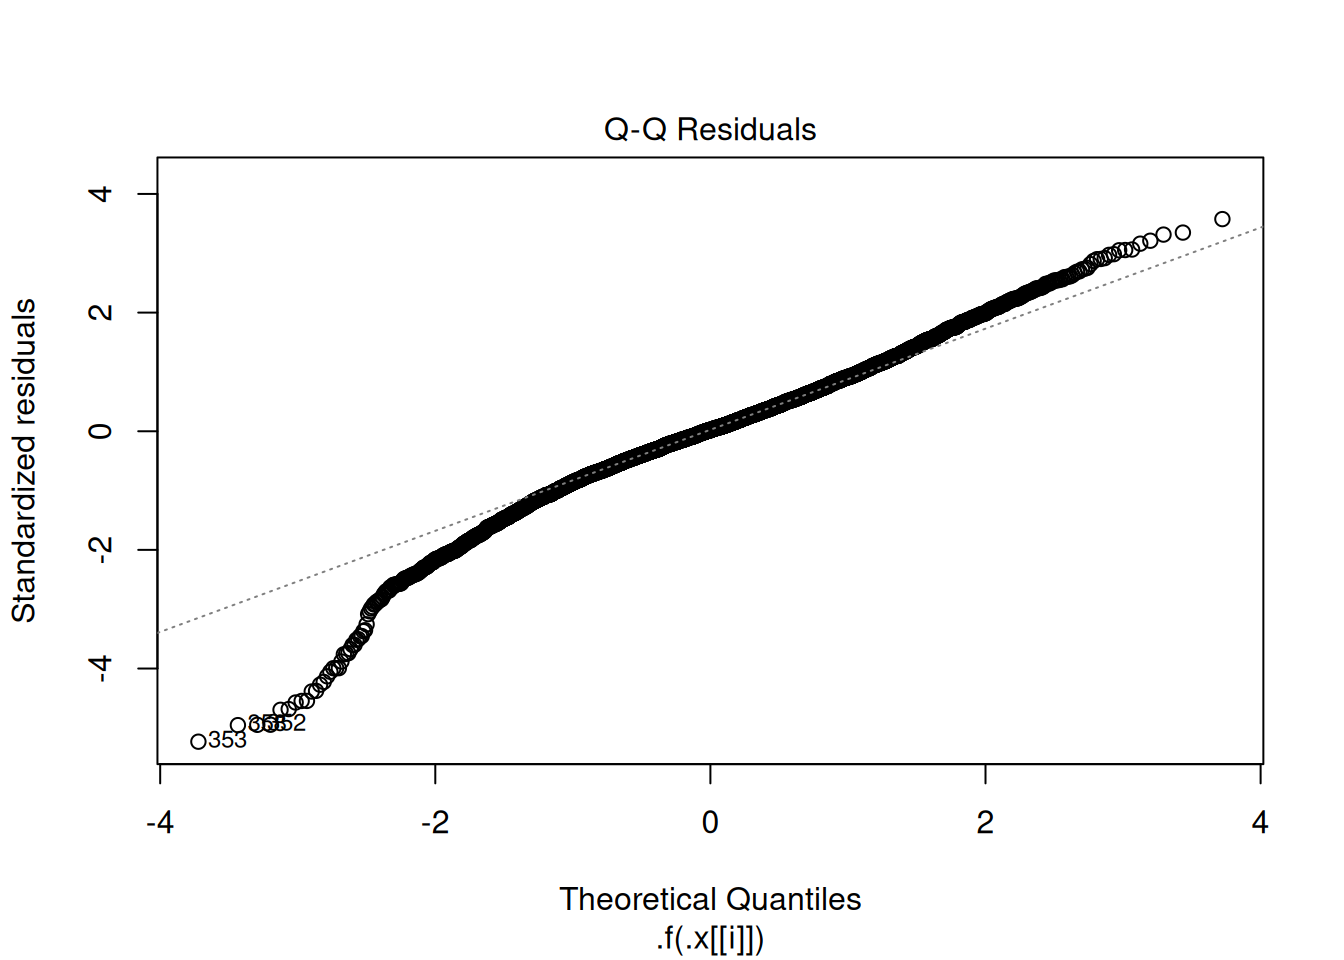</p>
</div></td>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>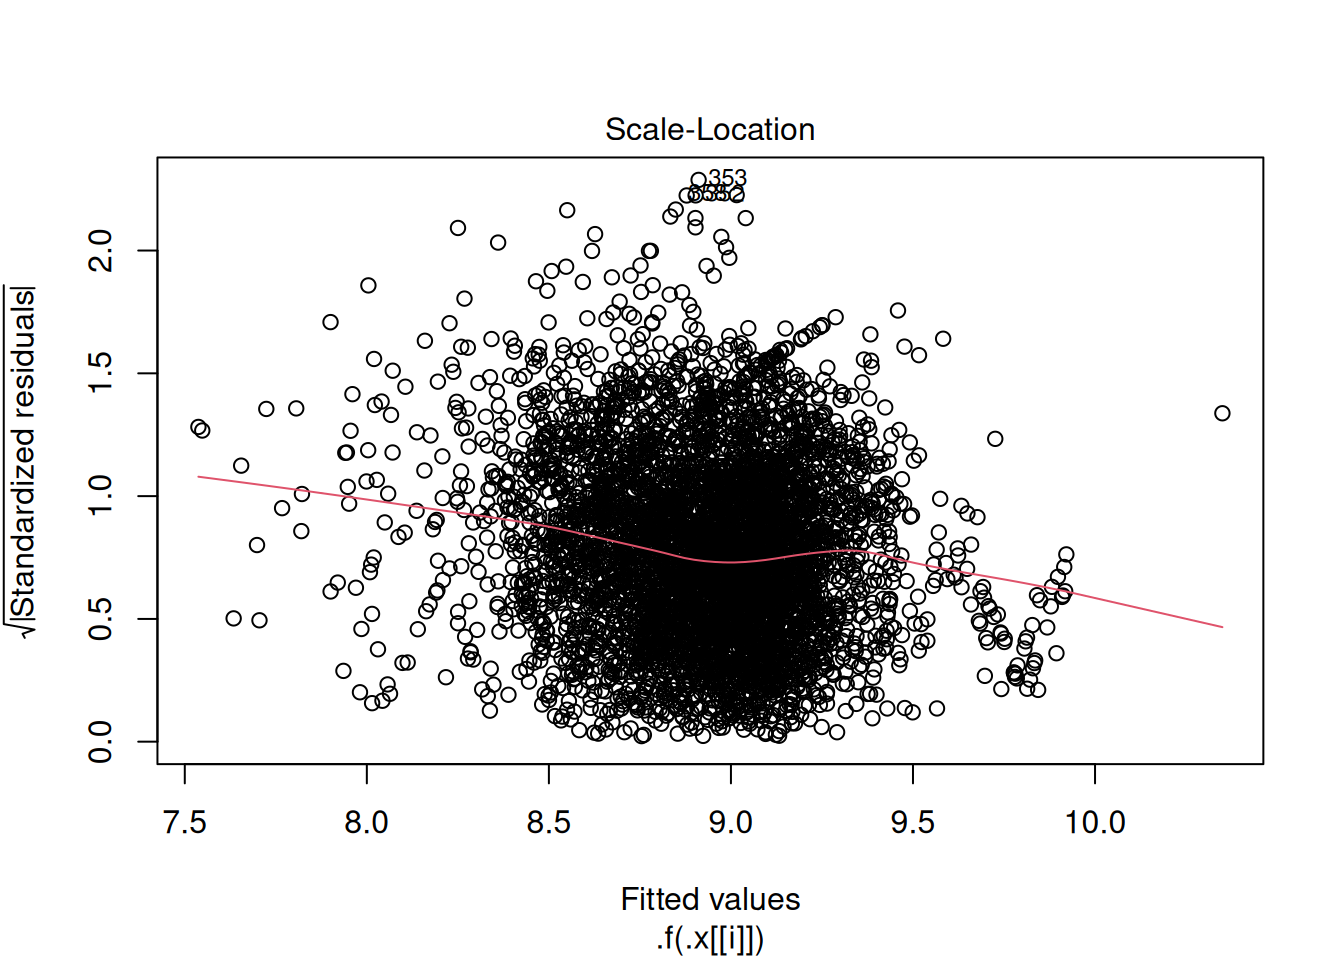</p>
</div></td>
</tr>
</tbody>
</table>

<table style="width:50%;">
<colgroup>
<col style="width: 50%" />
</colgroup>
<tbody>
<tr>
<td style="text-align: left;"><div class="cell-output-display" width="50.0%" data-layout-align="left">
<p>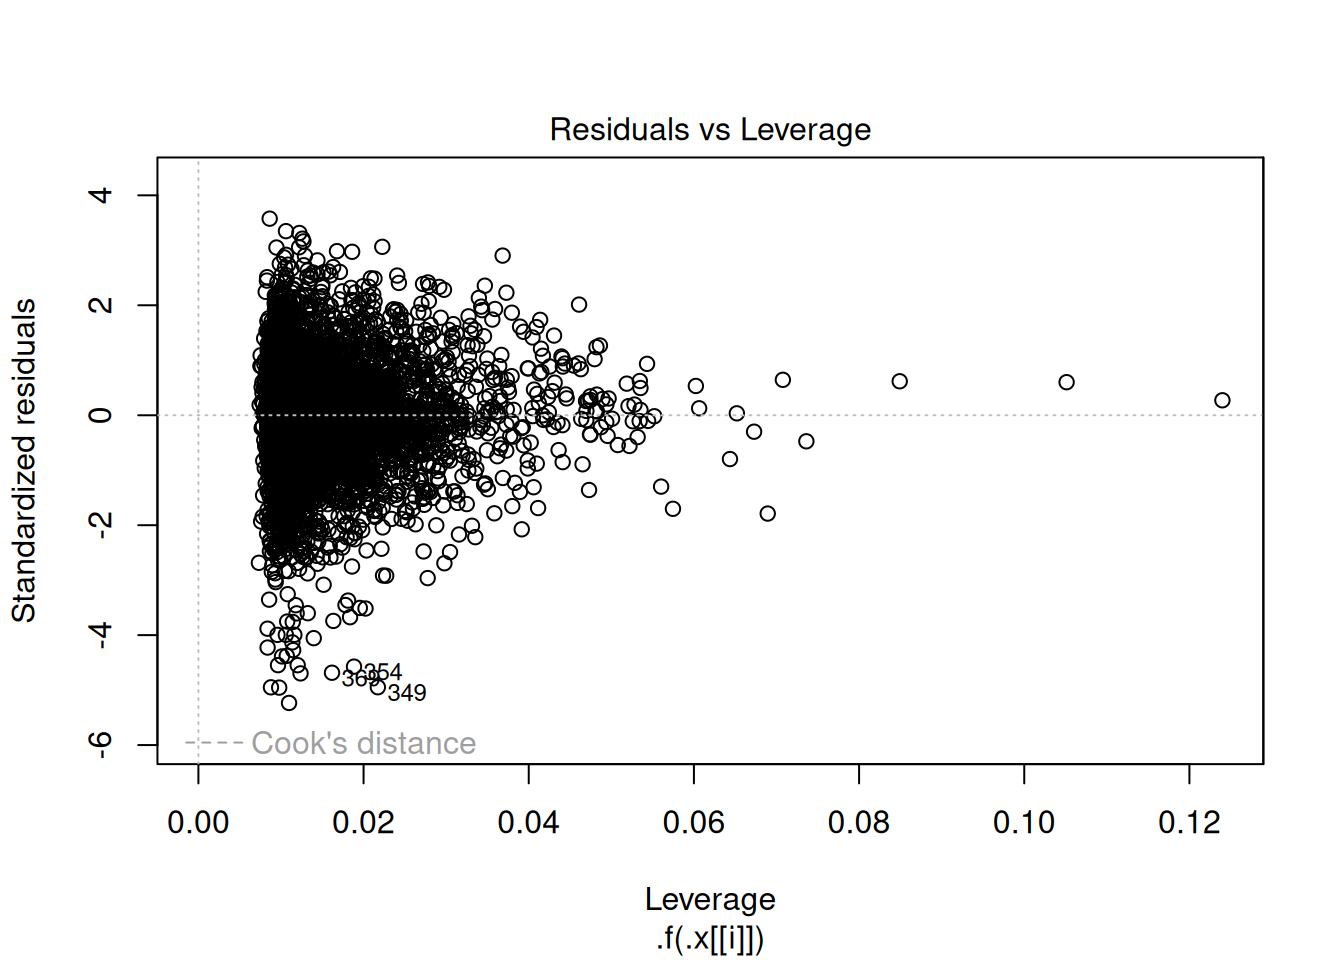</p>
</div></td>
</tr>
</tbody>
</table>